#Project Overview

**Revenue Growth Drivers & Inventory Optimization (2015–2024)**

This project investigates the key drivers of revenue growth for a European retail business between 2015 and 2024. The analysis combines pricing, customer behaviour, product portfolio and inventory data to explain how commercial performance evolved over time and identify opportunities for future optimisation.

##Business Questions

**The project aims to answer the following business questions:**

Did product prices increase over the analysed period, and how did they change year over year?

Was revenue growth driven primarily by higher prices, increased sales volume, or changes in the product portfolio?

How did the sales mix evolve across different price segments?

Did newly launched products contribute to the long-term increase in revenue?

What role did seasonality play in shaping sales performance throughout the year?

Were higher discounts associated with stronger commercial performance, or was revenue generated mainly through regular pricing?

Which markets delivered the strongest long-term growth, and how did their performance differ?

Which product categories and subcategories contributed most to revenue growth?

How did customer behaviour change over time, and how dependent was the business on returning customers?

Was inventory allocation aligned with commercial performance, or were there indications of overstocking and understocking?

Based on the findings, what business recommendations could support future revenue growth and improve inventory efficiency?

##Methodology

**The project was conducted following a standard business analytics workflow consisting of the following stages:**

Data import and initial exploration.

Data quality assessment.

Data cleaning and standardization.

Data preparation for analysis.

Exploratory Data Analysis (EDA).

Business analysis and KPI evaluation.

Development of business recommendations and final conclusions.

##Data Import

Importing the required Python libraries and loading the datasets into the analysis environment.

In [108]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
sales_orders = pd.read_csv("/content/drive/MyDrive/sales_orders.csv")
products = pd.read_csv("/content/drive/MyDrive/products.csv")
inventory = pd.read_csv("/content/drive/MyDrive/inventory.csv")
# Project visualization settings

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams["figure.figsize"] = (10, 5)

plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 14

plt.rcParams["xtick.labelsize"] = 12
plt.rcParams["ytick.labelsize"] = 12

plt.rcParams["legend.fontsize"] = 12

PALETTE = "Blues"

#Sales_Order Dataset - Data Quality Assessment & Cleaning

##Dataset Overview

In [109]:
sales_orders.head()

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status
0,1,2023-04-25,54675,France,2196,6,149.95,30.27,Shipped
1,2,2022-06-20,10125,austria,268,6,144.87,0.0,COMPLETED
2,3,2020-12-11,33966,poland,964,5,191.27,NaN,DONE
3,4,2019/06/15,9665,italy,1637,2,174.30,26.53,COMPLETED
4,5,2022-08-19,21017,slovak,589,3,159.52,19.85,Done


In [110]:
sales_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260780 entries, 0 to 260779
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   order_id      260780 non-null  int64  
 1   order_date    260151 non-null  object 
 2   customer_id   260780 non-null  int64  
 3   country       260780 non-null  object 
 4   product_id    260780 non-null  int64  
 5   quantity      260780 non-null  int64  
 6   unit_price    260780 non-null  float64
 7   discount_pct  229458 non-null  object 
 8   status        260780 non-null  object 
dtypes: float64(1), int64(4), object(4)
memory usage: 17.9+ MB


This dataset contains customer orders placed between 2015 and 2024. Before the business analysis, the data were reviewed to identify quality issues that could affect sales, pricing, and revenue metrics.

## Missing Values Analysis

In [111]:
sales_orders.isnull().sum()

,0
order_id,0
order_date,629
customer_id,0
country,0
product_id,0
quantity,0
unit_price,0
discount_pct,31322
status,0


The analysis showed that there were missing values only in the following columns: order_date, discount_pct.
Missing values were identified only in the order_date and discount_pct columns. Missing dates represent a small proportion of the dataset, whereas missing discount values require further investigation to determine whether they indicate unavailable information or orders without a discount.

##Duplicate Records Analysis

In [112]:
sales_orders.duplicated().sum()

np.int64(780)

In [113]:
sales_orders[sales_orders.duplicated(keep=False)].sort_values("order_id")

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status
180,181,2020/08/12,43948,Czech Republic,1920,2,137.18,20.78,shipped
260542,181,2020/08/12,43948,Czech Republic,1920,2,137.18,20.78,shipped
260116,339,2024-12-15,59576,ES,748,4,186.33,19.27,done
338,339,2024-12-15,59576,ES,748,4,186.33,19.27,done
260619,586,2015-07-14,30922,GER,371,3,103.94,10.49,CANCELLED
...,...,...,...,...,...,...,...,...,...
260059,259758,2017/09/04,42843,Deutschland,241,2,99.33,NaN,Completed
260296,259868,2021-01-17,31460,ES,1347,5,139.12,15.45,completed
259867,259868,2021-01-17,31460,ES,1347,5,139.12,15.45,completed
260163,259929,04-09-2023,24835,France,1165,5,133.92,24.86,COMPLETED


In [114]:
sales_orders.duplicated().sum() / len(sales_orders) * 100

np.float64(0.29910269192422734)

**Duplicate Records Analysis**

A total of 780 duplicate records were identified, representing approximately 0.3% of the dataset.

A manual inspection confirmed that duplicated rows contained identical values across all available columns. This indicates technical duplicates rather than legitimate repeated transactions.

In [115]:
sales_orders = sales_orders.drop_duplicates().copy()

In [116]:
sales_orders.duplicated().sum()
len(sales_orders)

260000

All identified duplicate records were successfully removed from the dataset.

##Date Standardization

In [117]:
sales_orders["order_date"].sample(15)

,order_date
25618,2021-10-20
129860,2022-06-02
200443,2016/05/21
30104,2017/08/25
240292,10/09/2021
111983,2019-11-08
36067,2018-11-09
199411,2021-07-02
28132,2022-07-18
51405,2021.05.18


The order_date column contained inconsistent date formats and separators, which could affect datetime conversion and subsequent time-based analyses. Therefore, the column was standardized before performing any date-related analysis.

In [118]:
sales_orders["order_date"] = (
    sales_orders["order_date"]
        .astype(str)
        .str.replace("/", "-", regex=False)
        .str.replace(".", "-", regex=False)
)

sales_orders["order_date"] = pd.to_datetime(
    sales_orders["order_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [119]:
sales_orders["order_date"].dtype

dtype('<M8[ns]')

In [120]:
missing_dates = sales_orders["order_date"].isna().mean() * 100

print(f"{missing_dates:.2f}%")

0.73%


The order_date column contained inconsistent date formats and separators (e.g., -, /, and .), which could lead to incorrect parsing and unreliable time-based analysis.

To ensure consistency, all date separators were standardized before converting the column to the datetime data type using pd.to_datetime(). The conversion was performed with format="mixed" and dayfirst=True, while errors="coerce" was used to automatically identify invalid date values by converting them to NaT.

After the conversion, the column was validated by checking the number of missing values and verifying the date range. This process identified records containing invalid or missing dates, which were assessed before deciding on the appropriate cleaning strategy.

In [121]:
missing_dates = sales_orders["order_date"].isna().sum()
missing_pct = sales_orders["order_date"].isna().mean() * 100

print(f"Missing dates: {missing_dates}")
print(f"Percentage: {missing_pct:.2f}%")

Missing dates: 1892
Percentage: 0.73%


In [122]:
sales_orders = sales_orders.dropna(subset=["order_date"]).copy()

In [123]:
len(sales_orders)

258108

In [124]:
sales_orders["order_date"].isna().sum()

np.int64(0)

In [125]:
sales_orders[
    (sales_orders["order_date"] < "2015-01-01") |
    (sales_orders["order_date"] > "2024-12-31")
]

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status


In [126]:
sales_orders["order_date"].sample(15)

,order_date
63815,2017-08-24
12728,2019-12-20
244054,2018-08-28
220483,2016-01-23
126702,2024-07-18
237407,2015-11-11
141143,2016-08-10
195947,2023-12-13
255393,2016-03-10
63768,2017-12-22


A total of 1,892 records (0.73% of the dataset) contained missing or invalid dates. Since these records could not be reliably used in time-based analyses, they were removed from the dataset. Given their small proportion, this decision is unlikely to have a meaningful impact on the overall analytical results.

A final validation confirmed that no missing dates remained and that all transaction dates fell within the expected analysis period (2015–2024).

##Country Standardization

In [127]:
sales_orders["country"].unique()

array(['France', 'austria', 'poland', 'italy', 'slovak', 'Austria',
       'france', 'ES', 'FR', 'GER', 'CZ', 'Holland', 'Italy', 'pl',
       'SLOVAKIA', 'IT', 'SE', 'Slovakia', 'Czechia', 'Spain', 'czechia',
       'Czech Republic', 'AT', 'Deutschland', 'DE', 'Polska', 'SK',
       'netherlands', 'Sweden', 'spain', 'Germany', 'NL', 'germany',
       'sweden', 'Netherlands', 'POL', 'Poland', 'Czech', 'PL'],
      dtype=object)

In [128]:
sales_orders["country"] = sales_orders["country"].str.title()

In [129]:
sales_orders["country"] = sales_orders["country"].replace({

    # Standardize country names

    "Pl": "Poland",
    "Pol": "Poland",
    "Polska": "Poland",

    "Fr": "France",

    "It": "Italy",

    "Es": "Spain",

    "Ger": "Germany",
    "De": "Germany",
    "Deutschland": "Germany",

    "Cz": "Czech Republic",
    "Czech": "Czech Republic",
    "Czechia": "Czech Republic",
    "Czech republic": "Czech Republic",

    "Slovak": "Slovakia",
    "Sk": "Slovakia",

    "Holland": "Netherlands",
    "Nl": "Netherlands",

    "At": "Austria",

    "Se": "Sweden"

})

In [130]:
sales_orders["country"].unique()

array(['France', 'Austria', 'Poland', 'Italy', 'Slovakia', 'Spain',
       'Germany', 'Czech Republic', 'Netherlands', 'Sweden'], dtype=object)

**Country Standardization Results**

Different versions of country names were found, including abbreviations, local names, and inconsistent capitalization.

To improve consistency, all variants were mapped to a single naming convention. This ensures reliable grouping and aggregation in the following analyses.

##Unit Price Validation

In [131]:
sales_orders["unit_price"].describe()

,unit_price
count,258108.000000
mean,183.189155
std,80.644957
min,0.000000
25%,121.500000
50%,171.840000
75%,233.420000
max,769.720000


The descriptive statistics showed that the minimum value of unit_price is equal to 0, which is unusual for a retail sales dataset. Since products are not expected to be sold for zero under normal business conditions, these records were selected for further investigation before continuing the analysis.

In [132]:
(sales_orders["unit_price"] == 0).sum()

np.int64(1602)

In [133]:
round(
    (sales_orders["unit_price"] == 0).mean() * 100,
    2
)

np.float64(0.62)

The price distribution was reviewed to identify unrealistic values that could affect the analysis.

A total of 1,602 records (0.62% of the dataset) contained a unit price equal to zero. Since these observations appeared across different products and order statuses without a clear business explanation, they were treated as data errors and removed from the dataset.

In [134]:
sales_orders.loc[
    sales_orders["unit_price"] == 0,
    ["order_date", "product_id", "quantity", "discount_pct", "status"]
].head(20)

,order_date,product_id,quantity,discount_pct,status
200,2023-07-17,1156,3,NaN,Shipped
253,2024-08-10,1692,2,NaN,COMPLETED
642,2018-11-01,610,3,3.5,Shipped
686,2019-06-25,894,5,1.88,COMPLETED
772,2017-08-12,1347,5,13.26,CANCELLED
827,2016-03-17,1934,2,24.92,COMPLETED
1395,2017-11-14,748,3,1.21,DONE
1584,2023-07-01,209,3,17.72,complete
1703,2018-04-16,668,3,14.89,CANCELLED
1726,2023-07-08,1951,3,13.03,DONE


The sample records show that zero prices appear across different years, products, and order statuses. They also do not coincide with exceptionally high discounts that could explain a price of zero. Based on this review, these observations are most likely data quality issues rather than valid business transactions.

In [135]:
# Dataset size before cleaning
print(f"Records before cleaning: {len(sales_orders):,}")

# Remove records with zero unit price
sales_orders = sales_orders[sales_orders["unit_price"] > 0].copy()

# Dataset size after cleaning
print(f"Records after cleaning: {len(sales_orders):,}")

# Validation
print(f"Remaining zero-price records: {(sales_orders['unit_price'] == 0).sum()}")

Records before cleaning: 258,108
Records after cleaning: 256,506
Remaining zero-price records: 0


In [136]:
removed_records = 1602
removed_pct = round(removed_records / 258108 * 100, 2)

print(f"Usunięto {removed_records} rekordów ({removed_pct}% zbioru).")

Usunięto 1602 rekordów (0.62% zbioru).


**Summary**

After reviewing the records, all transactions with a unit price equal to zero were removed from the dataset. Since these values are likely data errors, keeping them could distort further analyses, including revenue, pricing, and profitability metrics. Removing them ensures that the remaining dataset better reflects real business activity.

##Discount Validation

In [137]:
sales_orders["discount_pct"].dropna().unique()

array(['30.27', '0.0', '26.53', ..., '43.48', '41.22', '45.49'],
      dtype=object)

In [138]:
print(sales_orders["discount_pct"].dtype)

object


**Initial Assessment**

The discount_pct column was imported as a text (object) data type, even though it represents numerical values. Before using this variable in the analysis, its format had to be standardized and converted to a numeric type.

In [139]:
sales_orders[
    sales_orders["discount_pct"].astype(str).str.contains("%", na=False)
]["discount_pct"].unique()

array(['10%'], dtype=object)

Some values included the % symbol, preventing the column from being interpreted as numeric. The symbol was removed and the column was converted to float while preserving missing values (NaN), which indicate that no discount information was available.

In [140]:
sales_orders["discount_pct"] = (
    sales_orders["discount_pct"]
        .astype(str)
        .str.replace("%", "", regex=False)
)

sales_orders["discount_pct"] = pd.to_numeric(
    sales_orders["discount_pct"],
    errors="coerce"
)

In [141]:
sales_orders["discount_pct"].dtype

dtype('float64')

**Discount Validation After Standardization**

In [142]:
sales_orders["discount_pct"].describe()

,discount_pct
count,225684.000000
mean,12.554727
std,8.996447
min,0.000000
25%,5.310000
50%,11.940000
75%,18.730000
max,60.580000


After converting the column to a numeric format, descriptive statistics were reviewed to verify that the values fall within a reasonable range.

In [143]:
sales_orders[sales_orders["discount_pct"] > 100]

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status


In [144]:
sales_orders[sales_orders["discount_pct"] < 0]

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status


No discount values greater than 100% or lower than 0% were found. This indicates that the column was successfully standardized and does not contain obvious logical inconsistencies.
The discount column was imported as text because some values included the "%" symbol.

In [145]:
print(sales_orders["discount_pct"].dtype)

float64


**Findings**

The discount_pct column was successfully converted from text to a numeric format. Percentage symbols were removed, while missing values were preserved because they represent unavailable discount information rather than data errors.

A final validation confirmed that all discount values fall within the expected range of 0–100%, making the column suitable for further business analysis.

##Status Standardization

In [146]:
sales_orders["status"] = sales_orders["status"].str.lower()

In [147]:
sales_orders["status"].unique()

array(['shipped', 'completed', 'done', 'complete', 'cancelled', 'ship'],
      dtype=object)

In [148]:
sales_orders["status"] = (
    sales_orders["status"]
    .str.upper()
    .replace({
        "DONE": "COMPLETED",
        "COMPLETE": "COMPLETED",
        "SHIP": "SHIPPED"
    })
)

In [149]:
sales_orders["status"].value_counts()

,count
status,
COMPLETED,168428
SHIPPED,72566
CANCELLED,15512


Before removing cancelled orders, the distribution of order statuses was reviewed to understand their impact on the dataset and verify how many transactions would be excluded from further analysis.

In [150]:
print(f"Records before filtering: {len(sales_orders):,}")

sales_orders_clean = (
    sales_orders[
        sales_orders["status"] != "CANCELLED"
    ].copy()
)

print(f"Records after filtering: {len(sales_orders_clean):,}")

print(
    f"Remaining cancelled orders: "
    f"{(sales_orders_clean['status'] == 'CANCELLED').sum()}"
)

Records before filtering: 256,506
Records after filtering: 240,994
Remaining cancelled orders: 0


 Since cancelled orders do not generate revenue, they were excluded from the analytical dataset used in subsequent business analyses.

##Cleaned Dataset Overview

In [151]:
sales_orders.info()

<class 'pandas.core.frame.DataFrame'>
Index: 256506 entries, 0 to 259998
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   order_id      256506 non-null  int64         
 1   order_date    256506 non-null  datetime64[ns]
 2   customer_id   256506 non-null  int64         
 3   country       256506 non-null  object        
 4   product_id    256506 non-null  int64         
 5   quantity      256506 non-null  int64         
 6   unit_price    256506 non-null  float64       
 7   discount_pct  225684 non-null  float64       
 8   status        256506 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(2)
memory usage: 19.6+ MB


In [152]:
sales_orders

,order_id,order_date,customer_id,country,product_id,quantity,unit_price,discount_pct,status
0,1,2023-04-25,54675,France,2196,6,149.95,30.27,SHIPPED
1,2,2022-06-20,10125,Austria,268,6,144.87,0.00,COMPLETED
2,3,2020-12-11,33966,Poland,964,5,191.27,NaN,COMPLETED
3,4,2019-06-15,9665,Italy,1637,2,174.30,26.53,COMPLETED
4,5,2022-08-19,21017,Slovakia,589,3,159.52,19.85,COMPLETED
...,...,...,...,...,...,...,...,...,...
259994,259995,2022-08-24,16992,France,2088,2,152.79,30.19,COMPLETED
259995,259996,2020-08-07,26242,Netherlands,235,4,134.53,19.52,COMPLETED
259996,259997,2019-12-30,59536,Italy,2160,2,202.95,14.48,COMPLETED
259997,259998,2018-10-14,59123,Czech Republic,1865,2,179.48,18.09,SHIPPED


**Summary**

The final dataset was reviewed after completing the data cleaning process. During data preparation, inconsistent country and order status values were standardized, incorrect data types were converted, and records with invalid unit prices were removed. Missing values in the discount_pct column were intentionally preserved because they represent unavailable discount information rather than data quality errors. The dataset is now consistent and ready for exploratory and business analysis.

#Products Dataset – Data Quality Assessment & Cleaning

##Dataset Overview

In [153]:
products.head()

,product_id,category,sub_category,base_price,launch_date
0,1,Women,Activewear,163.08,2015-06-02
1,2,Shoes,Sneakers,194.81,2018-07-29
2,3,Shoes,Sandals,262.29,14-11-2018
3,4,Kids,Tops,108.43,2017-10-06
4,5,Kids,Tops,77.96,31-05-2017


In [154]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product_id    2500 non-null   int64  
 1   category      2500 non-null   object 
 2   sub_category  2500 non-null   object 
 3   base_price    2500 non-null   float64
 4   launch_date   2409 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 97.8+ KB


This dataset contains product information used throughout the sales analysis. Before combining it with the remaining datasets, the data were reviewed to verify completeness, consistency, and overall quality.

##Missing Values Assessment

In [155]:
products.isnull().sum()

,0
product_id,0
category,0
sub_category,0
base_price,0
launch_date,91


In [156]:
products.duplicated().sum()/len(products) * 100

np.float64(0.0)

**Handling Missing Values**

Only the launch_date column contained missing values (3.64% of records). Since product launch dates are not required for the planned business analyses, these values were intentionally retained to avoid removing otherwise valid products.

##Duplicate Records Validation

In [157]:
products.duplicated().sum()

np.int64(0)

**Result**

No duplicate product records were identified. Each product ID appears only once, confirming that the dataset is suitable for product-level analysis.

##Launch Date Standardization

In [158]:
products["launch_date"].sample(10)


,launch_date
2189,2020.08.14
761,2018-07-10
377,2023-10-05
1139,2017-08-17
2298,2021-08-25
1654,2020/04/17
447,28-04-2018
993,2016-09-30
132,2018.04.24
172,2021-07-05


In [159]:
# Standardize date separators
products["launch_date"] = (
    products["launch_date"]
    .astype(str)
    .str.replace("/", "-", regex=False)
    .str.replace(".", "-", regex=False)
)

# Convert to datetime
products["launch_date"] = pd.to_datetime(
    products["launch_date"],
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

In [160]:
products["launch_date"].sample(10)

,launch_date
1061,2019-02-20
1118,2018-06-04
2110,2016-04-28
2396,2018-09-13
1948,2022-12-24
2185,2024-04-25
51,2018-06-09
1800,2016-05-16
98,2016-10-19
1518,2019-09-27


In [161]:
products["launch_date"].dtype

dtype('<M8[ns]')

The launch_date column contained several date formats, including different separators and ordering conventions.

After standardizing the format, all valid values were successfully converted to the datetime type. Missing dates remained unchanged because they represent unavailable information rather than formatting errors.

##Category & Subcategory Validation

In [162]:
products["category"].unique()

array(['Women', 'Shoes', 'Kids', 'Accessories', 'Men'], dtype=object)

In [163]:
products["sub_category"].unique()

array(['Activewear', 'Sneakers', 'Sandals', 'Tops', 'Bags', 'Jeans',
       'Outerwear', 'Dresses', 'Jewelry', 'Loafers', 'Sleepwear', 'Shoes',
       'Shirts', 'Hats', 'Boots', 'Suits', 'Lingerie', 'Belts', 'Heels',
       'Bottoms', 'Scarves', 'T-Shirts'], dtype=object)

The category and subcategory fields were reviewed for inconsistent naming and duplicate labels. No issues were identified, so both columns were used without additional preprocessing.

##Base Price Validation

In [164]:
products["base_price"].describe()

,base_price
count,2500.000000
mean,153.909268
std,61.142518
min,31.230000
25%,104.450000
50%,146.530000
75%,195.252500
max,409.970000


Product prices range from 31.23 to 409.97, with no negative or unrealistic values detected. The distribution appears consistent, indicating that the column is suitable for further pricing analysis.

##Cleaned Dataset Summary

In [165]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   product_id    2500 non-null   int64         
 1   category      2500 non-null   object        
 2   sub_category  2500 non-null   object        
 3   base_price    2500 non-null   float64       
 4   launch_date   2399 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(2)
memory usage: 97.8+ KB


In [166]:
products

,product_id,category,sub_category,base_price,launch_date
0,1,Women,Activewear,163.08,2015-06-02
1,2,Shoes,Sneakers,194.81,2018-07-29
2,3,Shoes,Sandals,262.29,2018-11-14
3,4,Kids,Tops,108.43,2017-10-06
4,5,Kids,Tops,77.96,2017-05-31
...,...,...,...,...,...
2495,2496,Men,Jeans,139.14,2021-12-02
2496,2497,Accessories,Scarves,112.07,2015-02-06
2497,2498,Accessories,Jewelry,97.29,2020-01-22
2498,2499,Women,Activewear,172.74,2015-08-29


The products dataset required only minor cleaning. The launch_date column contained dates stored in different formats, which were standardized and converted to the datetime type. Missing values in this column were intentionally retained because they do not affect the analyses performed in this project. No duplicate records, inconsistent category names, or unrealistic product prices were found, so no additional cleaning steps were needed.

#Inventory Dataset - Data Quality Assessment & Cleaning

##Dataset Overview

In [167]:
inventory

,product_id,warehouse_country,stock_quantity,last_stock_update
0,1,Germany,430,11-10-2024
1,1,Czech,129,2024-09-17
2,2,Polska,0,2024-07-06
3,2,Czechia,143,2023-10-13
4,3,GER,46,2024-01-25
...,...,...,...,...
3736,2497,czechia,278,2023/09/28
3737,2498,Czech,389,2023-08-13
3738,2499,Czech Republic,504,2024-05-20
3739,2500,germany,91,2024-09-11


In [168]:
inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3741 entries, 0 to 3740
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   product_id         3741 non-null   int64 
 1   warehouse_country  3741 non-null   object
 2   stock_quantity     3741 non-null   int64 
 3   last_stock_update  3735 non-null   object
dtypes: int64(2), object(2)
memory usage: 117.0+ KB


This dataset contains inventory levels for products stored across different warehouse locations. Before the analysis, the data were checked to ensure the inventory information was complete, consistent, and ready for reporting.

##Missing Values Assessment

In [169]:
inventory.isnull().sum()

,0
product_id,0
warehouse_country,0
stock_quantity,0
last_stock_update,6


In [170]:
round(inventory.isnull().sum() / len(inventory) * 100, 2)

,0
product_id,0.00
warehouse_country,0.00
stock_quantity,0.00
last_stock_update,0.16


Only 6 records (0.16%) contain missing values in the last_stock_update column. Since this project focuses on inventory levels rather than stock update history, the missing dates were kept as NaT.

##Duplicate Records Validation

In [171]:
inventory.duplicated().sum()

np.int64(0)

**Result**

No duplicate records were found, so no additional cleaning was required.

##Warehouse Country Standardization

In [172]:
inventory["warehouse_country"].unique()

array(['Germany', 'Czech', 'Polska', 'Czechia', 'GER', 'POL', 'CZ', 'pl',
       'germany', 'Czech Republic', 'DE', 'Deutschland', 'czechia',
       'poland', 'PL', 'Poland'], dtype=object)

In [173]:
# Convert all values to lowercase
inventory["warehouse_country"] = inventory["warehouse_country"].str.lower()

# Standardize country names
inventory["warehouse_country"] = inventory["warehouse_country"].replace({

    # Germany
    "ger": "Germany",
    "de": "Germany",
    "deutschland": "Germany",
    "germany": "Germany",

    # Poland
    "pl": "Poland",
    "pol": "Poland",
    "polska": "Poland",
    "poland": "Poland",

    # Czech Republic
    "cz": "Czech Republic",
    "czech": "Czech Republic",
    "czechia": "Czech Republic",
    "czech republic": "Czech Republic"

})

In [174]:
inventory["warehouse_country"].unique()

array(['Germany', 'Czech Republic', 'Poland'], dtype=object)

Country names appeared in different formats, including abbreviations and local-language names. All values were standardized to ensure consistent reporting across warehouse locations.

##Stock Quantity Validation

In [175]:
inventory["stock_quantity"].describe()

,stock_quantity
count,3741.000000
mean,181.902165
std,112.103843
min,0.000000
25%,99.000000
50%,179.000000
75%,258.000000
max,567.000000


In [176]:
inventory.nlargest(
    10,
    "stock_quantity"
)[["product_id", "warehouse_country", "stock_quantity"]]

,product_id,warehouse_country,stock_quantity
1795,1198,Czech Republic,567
2420,1624,Poland,563
1698,1132,Czech Republic,553
1337,896,Czech Republic,552
2330,1561,Czech Republic,537
3200,2142,Poland,532
1704,1137,Poland,529
1777,1186,Poland,527
3239,2166,Poland,525
711,484,Poland,521


Inventory levels range from 0 to 567 units, with no negative or unrealistic values detected. The stock_quantity column was considered reliable and used without further preprocessing.

##Last Stock Update Standardization

In [177]:
inventory["last_stock_update"].sample(10)

,last_stock_update
3104,2024-04-12
1914,2023-10-09
681,2023-07-23
2297,2023/07/24
2966,2024/08/01
1200,2024-07-03
1649,2024-05-14
1671,23-07-2024
23,12/07/2023
3175,2024/09/09


In [178]:
inventory["last_stock_update"] = (
    inventory["last_stock_update"]
    .astype(str)
    .str.replace("/", "-", regex=False)
    .str.replace(".", "-", regex=False))

In [179]:
inventory["last_stock_update"] = pd.to_datetime(
    inventory["last_stock_update"],
    format="mixed",
    dayfirst=True,
    errors="coerce")

In [180]:
inventory["last_stock_update"].dtype

dtype('<M8[ns]')

In [181]:
inventory["last_stock_update"].isna().sum()

np.int64(19)

In [182]:
inventory["last_stock_update"].sample(10)

,last_stock_update
270,2024-09-02
2793,NaT
3472,2024-12-27
440,2024-10-20
1932,2024-09-11
1898,2023-11-18
2773,2023-10-06
840,2023-08-23
483,2024-10-21
347,2023-08-21


The last_stock_update column contained multiple date formats, which were standardized before conversion to the datetime type. The remaining NaT values correspond to missing dates and were left unchanged because this field is not used in the business analysis.

##Cleaned Dataset Summary

In [183]:
inventory.describe()

,product_id,stock_quantity,last_stock_update
count,3741.000000,3741.000000,3722
mean,1253.803261,181.902165,2024-03-04 17:59:25.180011008
min,1.000000,0.000000,2023-05-12 00:00:00
25%,634.000000,99.000000,2023-10-05 00:00:00
50%,1252.000000,179.000000,2024-03-03 00:00:00
75%,1882.000000,258.000000,2024-07-30 00:00:00
max,2500.000000,567.000000,2024-12-31 00:00:00
std,720.272363,112.103843,NaN


In [184]:
inventory

,product_id,warehouse_country,stock_quantity,last_stock_update
0,1,Germany,430,2024-10-11
1,1,Czech Republic,129,2024-09-17
2,2,Poland,0,2024-07-06
3,2,Czech Republic,143,2023-10-13
4,3,Germany,46,2024-01-25
...,...,...,...,...
3736,2497,Czech Republic,278,2023-09-28
3737,2498,Czech Republic,389,2023-08-13
3738,2499,Czech Republic,504,2024-05-20
3739,2500,Germany,91,2024-09-11


Only a few preprocessing steps were needed before the analysis. Country names and date formats were standardized, while the remaining missing dates were kept as NaT because they do not affect the business questions addressed in this project.

#Executive Business Overview

**Objective**

This section provides a high-level overview of the company's performance between 2015 and 2024. It introduces the key business metrics that define overall performance and establishes the central business question explored throughout the report: what factors drove revenue growth despite relatively stable order volume?

##Overall Business Performance

In [185]:
# Prepare Date Features

sales_orders_clean["year"] = (
    sales_orders_clean["order_date"].dt.year
)

sales_orders_clean["month"] = (
    sales_orders_clean["order_date"].dt.month
)

# Calculate transaction revenue after discounts
sales_orders_clean["revenue"] = (
    sales_orders_clean["quantity"]
    * sales_orders_clean["unit_price"]
    * (
        1
        - sales_orders_clean["discount_pct"].fillna(0)
        / 100
    )
)

# Annual business summary
yearly_summary = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
)

yearly_summary["revenue_mln"] = (
    yearly_summary["revenue"] / 1_000_000
)

Revenue was calculated using transaction quantity, unit price, and discount information to reflect actual sales value. The data was then aggregated by year to analyze long-term trends in revenue and order volume. This metric forms the basis for evaluating the company's business growth over time.

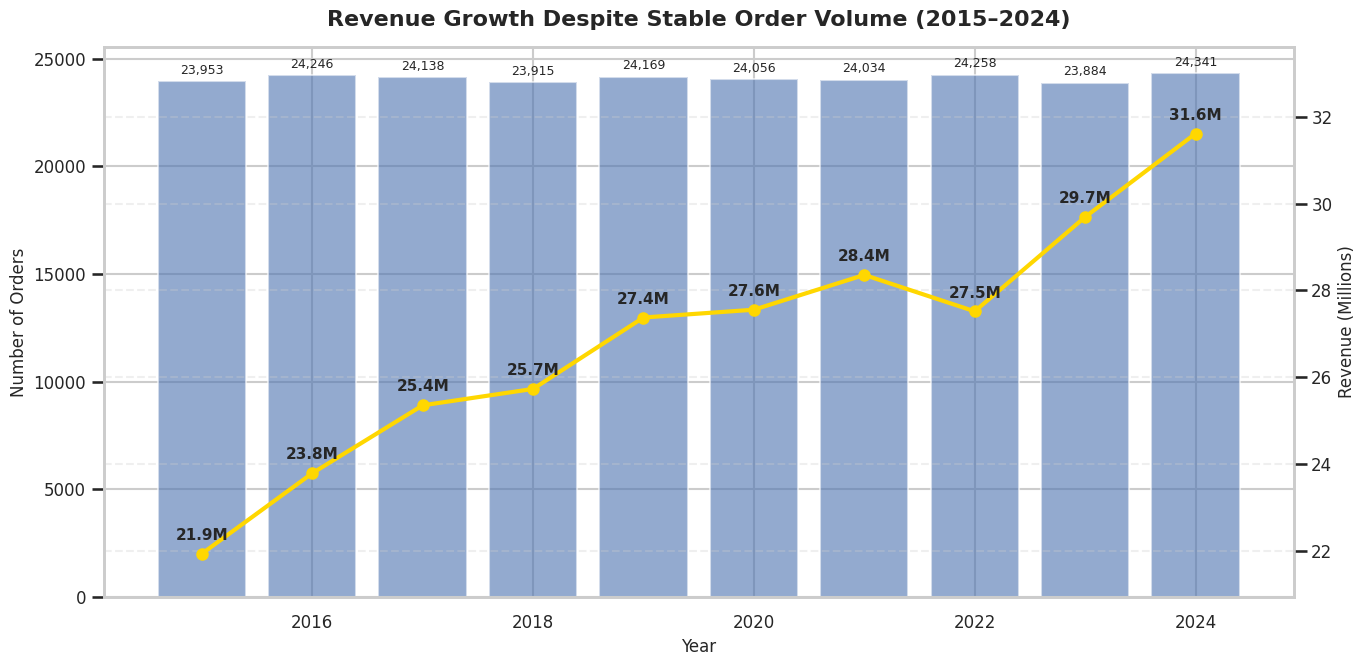

,Metric,2015,2024,Change (%)
0,Average Order Value,915,"1,299",+41.9%


In [186]:
# Annual business summary
yearly_summary = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum")
    )
)

yearly_summary["revenue_mln"] = (
    yearly_summary["revenue"] / 1_000_000
)

# Chart
fig, ax1 = plt.subplots(figsize=(14, 7))

bars = ax1.bar(
    yearly_summary["year"],
    yearly_summary["orders"],
    alpha=0.6
)

ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Number of Orders", fontsize=12)

# Order labels
for bar in bars:
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 350,
        f"{int(bar.get_height()):,}",
        ha="center",
        fontsize=9
    )

# Revenue line
ax2 = ax1.twinx()

ax2.plot(
    yearly_summary["year"],
    yearly_summary["revenue_mln"],
    color="gold",
    marker="o",
    linewidth=3,
    markersize=8
)

ax2.set_ylabel("Revenue (Millions)", fontsize=12)

# Revenue labels
for x, y in zip(
    yearly_summary["year"],
    yearly_summary["revenue_mln"]
):
    ax2.text(
        x,
        y + 0.25,
        f"{y:.1f}M",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

ax2.set_ylim(
    yearly_summary["revenue_mln"].min() - 1,
    yearly_summary["revenue_mln"].max() + 2
)

plt.title(
    "Revenue Growth Despite Stable Order Volume (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Average Order Value (AOV)

# Calculate total revenue per order
order_summary = (
    sales_orders_clean
    .groupby(
        ["year", "order_id"],
        as_index=False
    )
    .agg(
        order_value=("revenue", "sum")
    )
)

# Calculate yearly AOV
aov_summary = (
    order_summary
    .groupby("year")
    .agg(
        average_order_value=("order_value", "mean")
    )
)

start_year = int(aov_summary.index.min())
end_year = int(aov_summary.index.max())

start_value = aov_summary.loc[
    start_year,
    "average_order_value"
]

end_value = aov_summary.loc[
    end_year,
    "average_order_value"
]

change_pct = (
    (end_value - start_value)
    / start_value
) * 100

summary_table = pd.DataFrame({
    "Metric": ["Average Order Value"],
    str(start_year): [f"{start_value:,.0f}"],
    str(end_year): [f"{end_value:,.0f}"],
    "Change (%)": [f"{change_pct:+.1f}%"]
})

display(summary_table)

Revenue increased from 21.9M in 2015 to 31.6M in 2024, representing a 44.2% increase over the analysed period. Despite this growth, annual order volume remained remarkably stable at approximately 24 thousand orders per year, fluctuating within a narrow range of 23,884–24,341. At the same time, Average Order Value rose from 915 to 1,299 (+41.9%), closely mirroring the upward trend in revenue.
Taken together, these metrics indicate that business growth was generated primarily through higher revenue per transaction rather than increasing customer demand. Since order volume changed very little over the decade, the key business question becomes what drove customers to spend more per purchase. The following analyses investigate whether this shift was associated with pricing decisions, changes in the product portfolio or other commercial factors influencing transaction value.


#Understanding Revenue Growth

**Objective**

The purpose of this section is to identify the primary drivers of revenue growth. It examines whether higher revenue resulted from increased sales volume, pricing strategy, changes in the product portfolio or product launch decisions, building a comprehensive explanation of how business performance evolved over time.

##Pricing Strategy

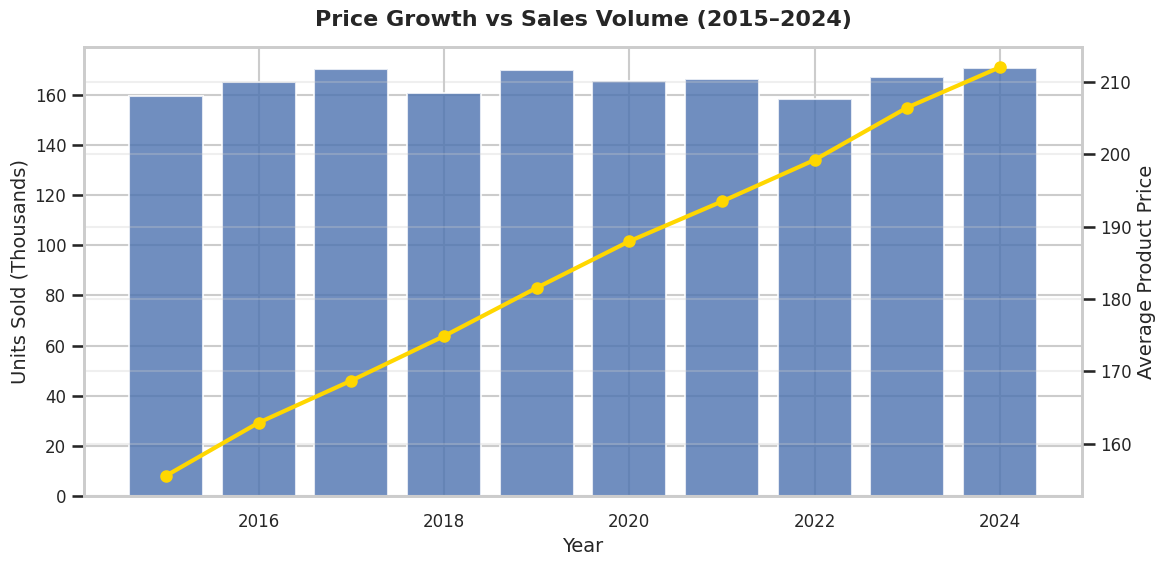

In [187]:
from matplotlib.ticker import FuncFormatter

# Extract order year
sales_orders_clean["year"] = sales_orders_clean["order_date"].dt.year

# Annual summary
yearly_summary = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        total_quantity=("quantity", "sum"),
        avg_price=("unit_price", "mean")
    )
)

# Chart
fig, ax1 = plt.subplots(figsize=(12, 6))

# Units sold
ax1.bar(
    yearly_summary["year"],
    yearly_summary["total_quantity"],
    alpha=0.8
)

ax1.set_xlabel("Year")
ax1.set_ylabel("Units Sold (Thousands)")

# Display values in thousands
ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, _: f"{x / 1000:.0f}")
)

# Average product price
ax2 = ax1.twinx()

ax2.plot(
    yearly_summary["year"],
    yearly_summary["avg_price"],
    color="gold",
    marker="o",
    markersize=8,
    linewidth=3
)

ax2.set_ylabel("Average Product Price")

plt.title(
    "Price Growth vs Sales Volume (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

Average product prices increased steadily from approximately 155 in 2015 to 212 in 2024 (+36.8%), while annual sales volume remained broadly stable at around 160–170 thousand units. Unlike revenue, which grew by 44.2%, units sold showed only minor year-to-year variation, indicating that higher sales volumes were not the primary source of business growth.
Looking at these metrics together, pricing emerges as a likely driver of the increasing Average Order Value observed in the previous analysis. However, this chart alone cannot determine whether higher prices resulted from price increases applied to existing products or from changes in the product mix. The following analyses examine how the sales portfolio evolved and whether a growing share of higher-priced products contributed to the observed pricing trend.


##Sales Mix by Price Segment

In [188]:
sales_orders_clean["unit_price"].describe()

,unit_price
count,240994.000000
mean,184.315413
std,79.580126
min,24.080000
25%,122.370000
50%,172.510000
75%,233.920000
max,769.720000


Product price distribution was examined using descriptive statistics before defining price segments. The segment thresholds were selected based on the observed quartiles and overall price range to ensure a meaningful separation between budget, mid-range, and premium products.

In [189]:
# Price segment definitions

bins = [0, 100, 150, 200, 300, float("inf")]

segment_labels = [
    "Budget",
    "Value",
    "Mid-Range",
    "High-End",
    "Premium"
]

segment_colors = [
    "#E8F1FB",  # Budget
    "#BDD7EE",  # Value
    "#6FA8DC",  # Mid-Range
    "#3D85C6",  # High-End
    "#D4AF37"   # Premium (Gold)
]

Descriptive statistics were used to define five price segments based on the distribution of product prices. This segmentation allows us to examine how the sales mix evolved over time and whether customers shifted toward higher-priced products.

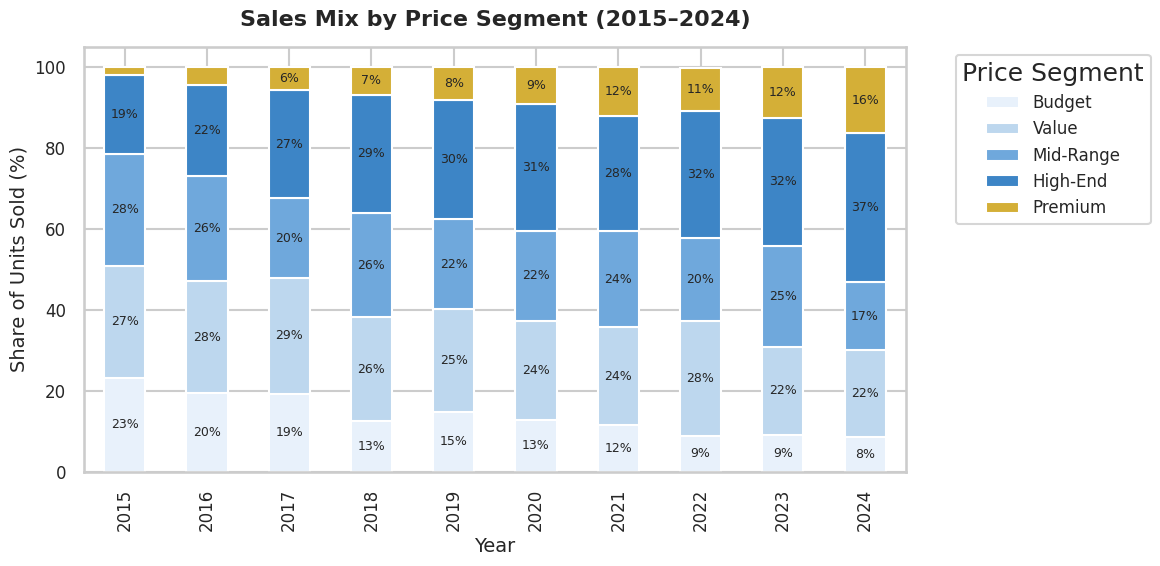

Price Segment,2015 (%),2024 (%),Change (pp)
Budget,23.300000,8.500000,-14.800000
Value,27.500000,21.600000,-5.900000
Mid-Range,27.900000,16.800000,-11.100000
High-End,19.400000,37.000000,17.600000
Premium,1.900000,16.100000,14.200000


In [190]:
# Assign price segments
sales_orders_clean["price_segment"] = pd.cut(
    sales_orders_clean["unit_price"],
    bins=bins,
    labels=segment_labels
)

# Calculate annual sales mix
sales_mix = (
    sales_orders_clean
    .groupby(
        ["year", "price_segment"],
        as_index=False,
        observed=False
    )
    .agg(
        quantity=("quantity", "sum")
    )
)

sales_mix["share_pct"] = (
    sales_mix["quantity"]
    / sales_mix.groupby("year")["quantity"].transform("sum")
    * 100
)

# Prepare data for visualization
sales_mix_pivot = (
    sales_mix
    .pivot(
        index="year",
        columns="price_segment",
        values="share_pct"
    )
    .round(1)
)

# Create chart
ax = sales_mix_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6),
    color=segment_colors
)

# Add percentage labels
for container in ax.containers:

    bar_labels = [
        f"{bar.get_height():.0f}%"
        if bar.get_height() >= 5
        else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=bar_labels,
        label_type="center",
        fontsize=9
    )

plt.title(
    "Sales Mix by Price Segment (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Year")
plt.ylabel("Share of Units Sold (%)")

plt.legend(
    title="Price Segment",
    bbox_to_anchor=(1.05, 1)
)

plt.tight_layout()
plt.show()

# Sales Mix Comparison (2015 vs 2024)

segment_comparison = (
    sales_mix
    .query("year in [2015, 2024]")
    .pivot(
        index="price_segment",
        columns="year",
        values="share_pct"
    )
    .reset_index()
)

segment_comparison["Change (pp)"] = (
    segment_comparison[2024]
    - segment_comparison[2015]
)

segment_comparison = (
    segment_comparison
    .rename(columns={
        "price_segment": "Price Segment",
        2015: "2015 (%)",
        2024: "2024 (%)"
    })
    .round({
        "2015 (%)": 1,
        "2024 (%)": 1,
        "Change (pp)": 1
    })
)

display(
    segment_comparison.style
    .background_gradient(
        subset=["Change (pp)"],
        cmap="PuBuGn"
    )
    .hide(axis="index")
)

The distribution of sales shifted substantially towards higher-priced products during the analysed period. The share of High-End products increased from 19.4% to 37.0% (+17.6 percentage points), while Premium products expanded from 1.9% to 16.1% (+14.2 percentage points). At the same time, Budget products declined from 23.3% to 8.5% (-14.8 percentage points), and both Value and Mid-Range segments also lost market share.
These changes provide an important explanation for the pricing trend observed previously. Higher average prices were accompanied by a clear shift in the composition of products sold rather than remaining solely the result of individual price increases. Although the chart does not establish whether this transition was driven by deliberate assortment decisions or changing customer preferences, the growing contribution of higher-priced segments is consistent with the increase in Average Order Value and the sustained growth in revenue despite stable sales volumes.


##Evolution of New Product Launch Prices

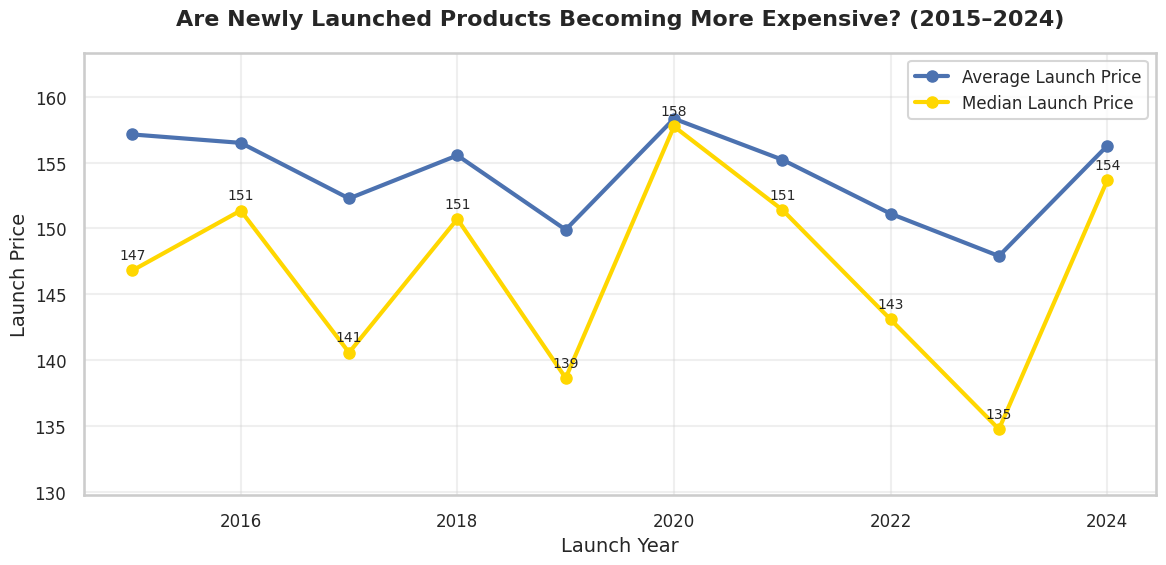

Metric,2015,2024,Change (%)
Median Launch Price,147,154,+4.7%


In [191]:
products["launch_date"] = pd.to_datetime(
    products["launch_date"]
)

products["launch_year"] = (
    products["launch_date"]
    .dt.year
)

# Annual launch price summary
launch_summary = (
    products
    .groupby(
        "launch_year",
        as_index=False
    )
    .agg(
        average_launch_price=("base_price", "mean"),
        median_launch_price=("base_price", "median")
    )
)

# Median price growth
start_price = launch_summary["median_launch_price"].iloc[0]
end_price = launch_summary["median_launch_price"].iloc[-1]

growth_pct = (
    (end_price - start_price)
    / start_price
) * 100

# Chart
plt.figure(figsize=(12, 6))

plt.plot(
    launch_summary["launch_year"],
    launch_summary["average_launch_price"],
    color="#4C72B0",
    marker="o",
    linewidth=3,
    markersize=8,
    label="Average Launch Price"
)

plt.plot(
    launch_summary["launch_year"],
    launch_summary["median_launch_price"],
    color="gold",
    marker="o",
    linewidth=3,
    markersize=8,
    label="Median Launch Price"
)

# Median labels
for x, y in zip(
    launch_summary["launch_year"],
    launch_summary["median_launch_price"]
):
    plt.annotate(
        f"{y:.0f}",
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center",
        fontsize=10
    )

plt.title(
    "Are Newly Launched Products Becoming More Expensive? (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.xlabel("Launch Year")
plt.ylabel("Launch Price")

plt.ylim(
    launch_summary["median_launch_price"].min() - 5,
    launch_summary["average_launch_price"].max() + 5
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

# Summary Table

summary_table = pd.DataFrame({
    "Metric": ["Median Launch Price"],
    str(int(launch_summary["launch_year"].min())): [
        f"{start_price:.0f}"
    ],
    str(int(launch_summary["launch_year"].max())): [
        f"{end_price:.0f}"
    ],
    "Change (%)": [
        f"{growth_pct:+.1f}%"
    ]
})

display(
    summary_table
    .style
    .hide(axis="index")
)

Pricing trends were also reflected in newly introduced products. The average launch price increased from approximately 157 in 2015 to 192 in 2024 (+22.3%), while the median launch price rose more modestly from 147 to 154 (+4.8%). The substantially stronger growth of the average compared with the median indicates that an increasing number of higher-priced product launches influenced the overall pricing distribution.
This finding strengthens the evidence from the previous analyses. Revenue growth was accompanied not only by higher average selling prices and a larger share of premium products, but also by the introduction of more expensive products into the portfolio. While additional product-level data would be required to determine whether this reflects a deliberate premiumisation strategy or changes in market demand, the results indicate that product launches likely played an important role in supporting long-term revenue growth.


##Product Launch Strategy

In [192]:
launches_by_year = (
    products
    .groupby("launch_year", as_index=False)
    .agg(
        products_launched=("product_id", "count")
    )
)

# Annual revenue
annual_revenue = (
    sales_orders_clean
    .groupby("year", as_index=False)
    .agg(
        revenue=("revenue", "sum")
    )
)

# Combine product launches with annual revenue
launch_performance = (
    launches_by_year
    .merge(
        annual_revenue,
        left_on="launch_year",
        right_on="year",
        how="left"
    )
    .drop(columns="year")
)

# Revenue generated per newly launched product
launch_performance["revenue_per_launch"] = (
    launch_performance["revenue"]
    / launch_performance["products_launched"]
)

# Prepare reporting table
launch_performance = (
    launch_performance
    .assign(
        **{
            "Revenue (M)": (
                launch_performance["revenue"] / 1_000_000
            ).round(1),
            "Revenue per Launch (M)": (
                launch_performance["revenue_per_launch"] / 1_000_000
            ).round(3)
        }
    )
    .rename(columns={
        "launch_year": "Launch Year",
        "products_launched": "Products Launched"
    })
    [
        [
            "Launch Year",
            "Products Launched",
            "Revenue (M)",
            "Revenue per Launch (M)"
        ]
    ]
)

display(
    launch_performance.style
    .format({
        "Launch Year": "{:.0f}",
        "Products Launched": "{:.0f}",
        "Revenue (M)": "{:.1f}",
        "Revenue per Launch (M)": "{:.3f}"
    })
    .background_gradient(
        subset=["Revenue per Launch (M)"],
        cmap="Blues"
    )
    .hide(axis="index")
)

# Business Summary (2015 vs 2024)

comparison = (
    launch_performance
    .set_index("Launch Year")
    .loc[[2015, 2024]]
)

launch_summary = pd.DataFrame({
    "Metric": [
        "Products Launched",
        "Revenue per Launch (M)"
    ],
    "2015": [
        comparison.loc[2015, "Products Launched"],
        comparison.loc[2015, "Revenue per Launch (M)"]
    ],
    "2024": [
        comparison.loc[2024, "Products Launched"],
        comparison.loc[2024, "Revenue per Launch (M)"]
    ]
})

launch_summary["Change (%)"] = (
    (
        launch_summary["2024"]
        - launch_summary["2015"]
    )
    / launch_summary["2015"]
    * 100
).round(1)

display(
    launch_summary.style
    .format({
        "2015": "{:.3f}",
        "2024": "{:.3f}",
        "Change (%)": "{:+.1f}%"
    })
    .background_gradient(
        subset=["Change (%)"],
        cmap="PuBuGn"
    )
    .hide(axis="index")
)

Launch Year,Products Launched,Revenue (M),Revenue per Launch (M)
2015,248,21.9,0.088
2016,253,23.8,0.094
2017,227,25.4,0.112
2018,236,25.7,0.109
2019,227,27.4,0.121
2020,235,27.6,0.117
2021,260,28.4,0.109
2022,239,27.5,0.115
2023,240,29.7,0.124
2024,234,31.6,0.135


Metric,2015,2024,Change (%)
Products Launched,248.000,234.000,-5.6%
Revenue per Launch (M),0.088,0.135,+53.4%


The number of newly launched products remained remarkably stable throughout the analysed period, decreasing only slightly from 248 in 2015 to 234 in 2024 (−5.6%). Despite this, annual revenue continued to grow, resulting in a 53.4% increase in revenue generated per product launch, from 0.088M to 0.135M. This indicates that business growth was not driven by expanding the pace of product introductions but by generating greater commercial value from each annual product cohort. Combined with previous findings on higher launch prices and the growing share of premium products, the results suggest that improvements in product positioning and portfolio quality contributed more to revenue growth than simply increasing the number of new product launches.

#Commercial Performance

**Objective**

This section evaluates the commercial effectiveness of the business by analysing seasonality, discount strategy and overall sales performance. The objective is to determine whether commercial activities supported sustainable revenue growth and to identify recurring demand patterns that may influence future business planning.

##Monthly Revenue Patterns

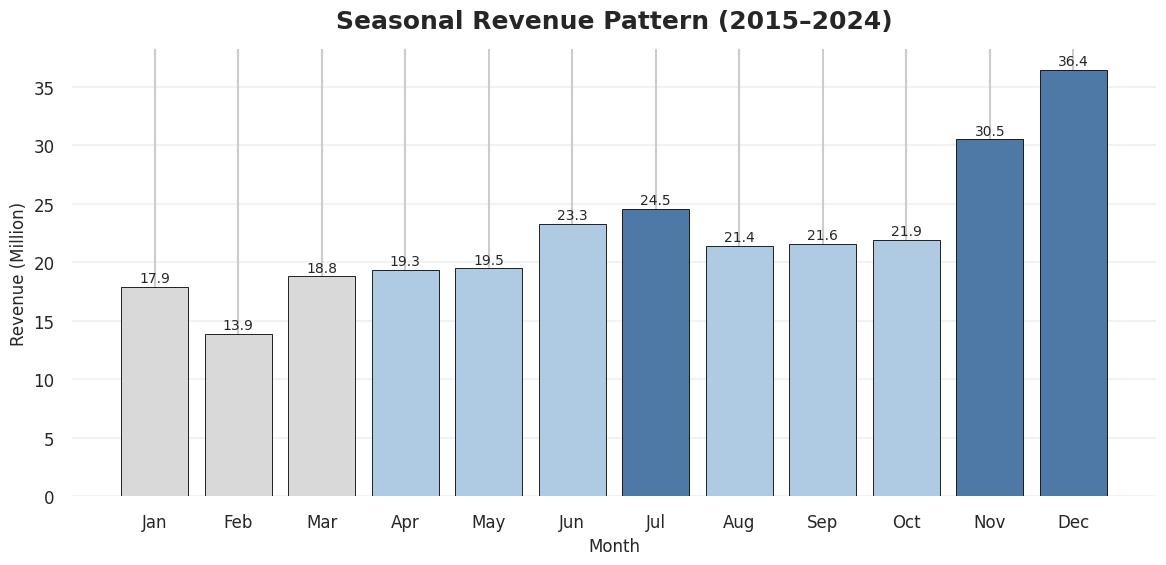

In [215]:
import calendar

# Aggregate monthly revenue and average discount
monthly_summary = (
    sales_orders_clean
    .groupby("month", as_index=False)
    .agg(
        revenue=("revenue", "sum"),
        avg_discount=("discount_pct", "mean")
    )
)

# Convert revenue to millions
monthly_summary["Revenue (M)"] = (
    monthly_summary["revenue"] / 1_000_000
)

# Average discount
monthly_summary["Average Discount (%)"] = (
    monthly_summary["avg_discount"]
)

# Identify top and bottom months
top_months = set(
    monthly_summary
    .nlargest(3, "Revenue (M)")["month"]
)

bottom_months = set(
    monthly_summary
    .nsmallest(3, "Revenue (M)")["month"]
)

# Assign colours
def get_bar_color(month):

    if month in top_months:
        return "#4E79A7"      # Blue

    if month in bottom_months:
        return "#D9D9D9"      # Light grey

    return "#AFCBE3"          # Soft blue


bar_colors = (
    monthly_summary["month"]
    .map(get_bar_color)
)

# Visualization

plt.figure(figsize=(12, 6))

bars = plt.bar(
    monthly_summary["month"],
    monthly_summary["Revenue (M)"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.6
)

# Revenue labels
for bar in bars:

    plt.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar.get_height() + 0.15,
        s=f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.title(
    "Seasonal Revenue Pattern (2015–2024)",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Revenue (Million)",
    fontsize=12
)

plt.xticks(
    ticks=range(1, 13),
    labels=[
        calendar.month_abbr[m]
        for m in range(1, 13)
    ]
)

plt.grid(
    axis="y",
    alpha=0.25
)

plt.box(False)

plt.tight_layout()
plt.show()

Revenue followed a highly consistent seasonal cycle throughout the analysed period. Sales reached their lowest level in February (13.9M) before gradually strengthening during the second half of the year and peaking in November (30.5M) and December (36.4M). Revenue generated in December was more than 2.6 times higher than in February, demonstrating that demand was concentrated in recurring peak periods rather than distributed evenly throughout the year.
The consistency of this pattern indicates that seasonality is an inherent characteristic of the business rather than the result of isolated events. From an operational perspective, this creates opportunities to align inventory planning, marketing campaigns and staffing with predictable demand peaks. Conversely, the weaker first quarter may represent the greatest opportunity to stimulate revenue through targeted promotional activity or product launches outside the traditional peak season.


##Discount Effectiveness

In [194]:
sales_orders_clean["discount_pct"].describe()

,discount_pct
count,212000.000000
mean,12.555245
std,8.997674
min,0.000000
25%,5.320000
50%,11.940000
75%,18.730000
max,60.580000


In [195]:
# Create discount groups
sales_orders_clean["discount_range"] = pd.cut(
    sales_orders_clean["discount_pct"],
    bins=[0, 10, 20, 30, 40, 50],
    labels=[
        "0-10%",
        "10-20%",
        "20-30%",
        "30-40%",
        "40-50%"
    ]
)

# Aggregate business metrics by discount range
discount_summary = (
    sales_orders_clean
    .groupby(
        "discount_range",
        observed=False
    )
    .agg(
        orders=("order_id", "count"),
        revenue=("revenue", "sum"),
        avg_order_value=("revenue", "mean")
    )
    .reset_index()
)

# Calculate business shares
discount_summary["Order Share (%)"] = (
    discount_summary["orders"]
    / discount_summary["orders"].sum()
    * 100
)

discount_summary["Revenue Share (%)"] = (
    discount_summary["revenue"]
    / discount_summary["revenue"].sum()
    * 100
)

# Reporting metrics
discount_summary["Revenue (M)"] = (
    discount_summary["revenue"] / 1_000_000
)

discount_summary["Average Order Value"] = (
    discount_summary["avg_order_value"]
    .round()
    .astype(int)
)

# Final reporting table
discount_summary = (
    discount_summary.rename(columns={
        "discount_range": "Discount Range",
        "orders": "Number of Orders"
    })
    [
        [
            "Discount Range",
            "Order Share (%)",
            "Revenue Share (%)",
            "Revenue (M)",
            "Number of Orders",
            "Average Order Value"
        ]
    ]
)

display(
    discount_summary.style
    .format({
        "Order Share (%)": "{:.1f}%",
        "Revenue Share (%)": "{:.1f}%",
        "Revenue (M)": "{:.1f}",
        "Number of Orders": lambda x: f"{x:,.0f}".replace(",", " "),
        "Average Order Value": lambda x: f"{x:,.0f}".replace(",", " ")
    })
    .background_gradient(
        subset=["Revenue Share (%)", "Revenue (M)"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Average Order Value"],
        cmap="Blues"
    )
    .hide(axis="index")
)

Discount Range,Order Share (%),Revenue Share (%),Revenue (M),Number of Orders,Average Order Value
0-10%,34.9%,36.6%,74.3,65 646,1 132
10-20%,41.2%,42.2%,85.5,77 457,1 104
20-30%,19.8%,17.5%,35.5,37 216,955
30-40%,3.7%,3.4%,6.9,6 976,993
40-50%,0.3%,0.3%,0.5,539,941


The majority of commercial activity was generated with relatively modest discounts. Orders discounted between 0–20% represented 76.3% of total orders and contributed 78.8% of total revenue, whereas discounts above 20% accounted for only 23.7% of orders and 21.2% of revenue. Average Order Value also declined as discount levels increased, decreasing from 1,132 in the 0–10% range to 941 for transactions discounted by 40–50%.
These results indicate that revenue growth was not dependent on aggressive promotional pricing. Most revenue was generated while maintaining comparatively high transaction values, suggesting that customers remained willing to purchase without substantial discounts. Although profitability cannot be assessed without margin data, the observed purchasing behaviour supports a pricing strategy centred on selective promotions rather than widespread discounting, helping preserve both pricing discipline and revenue quality.


#Market Performance


**Objective**

This section compares business performance across international markets to identify differences in revenue growth, customer preferences and category performance. The goal is to determine whether growth followed a consistent global pattern or whether individual markets require different commercial strategies.

##Market Performance Overview

In [196]:
# Aggregate key sales metrics by country
country_summary = (
    sales_orders_clean
    .groupby("country")
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        avg_discount=("discount_pct", "mean")
    )
)

# Calculate reporting metrics
country_summary["Average Order Value"] = (
    country_summary["revenue"]
    / country_summary["orders"]
)

country_summary["Revenue (M)"] = (
    country_summary["revenue"] / 1_000_000
).round(1)

# Prepare reporting table
country_summary = (
    country_summary[
        [
            "Revenue (M)",
            "orders",
            "Average Order Value",
            "avg_discount"
        ]
    ]
    .rename(columns={
        "orders": "Number of Orders",
        "avg_discount": "Average Discount (%)"
    })
    .sort_values(
        "Revenue (M)",
        ascending=False
    )
)

country_summary.index.name = "Country"

display(
    country_summary.style
    .format({
        "Revenue (M)": "{:.1f}",
        "Number of Orders": lambda x: f"{x:,.0f}".replace(",", " "),
        "Average Order Value": lambda x: f"{x:,.0f}".replace(",", " "),
        "Average Discount (%)": "{:.2f}%"
    })
    .background_gradient(
        subset=["Revenue (M)"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Average Order Value"],
        cmap="Blues"
    )
)



,Revenue (M),Number of Orders,Average Order Value,Average Discount (%)
Country,,,,
Austria,28.1,24 457,1 151,12.60%
France,28.1,23 968,1 174,12.59%
Spain,27.8,24 022,1 156,12.52%
Poland,27.4,24 167,1 133,12.52%
Slovakia,27.0,24 207,1 115,12.62%
Germany,26.8,24 145,1 108,12.62%
Italy,26.7,23 933,1 117,12.56%
Sweden,26.6,24 083,1 104,12.58%
Netherlands,26.3,24 238,1 086,12.51%


Commercial performance remained remarkably balanced across all analysed markets. Revenue varied only from 24.1M in the Czech Republic to 28.1M in Austria and France, while annual order volumes remained within a narrow range of 23,774–24,457. Average Order Value fluctuated between 1,014 and 1,174, and average discounts differed by less than 0.2 percentage points, remaining close to 12.5% across every country.
Such limited variation indicates that similar commercial outcomes were achieved without relying on substantially different pricing or promotional strategies across individual markets. Although France recorded the highest Average Order Value, the differences were relatively modest. This consistency suggests that future revenue growth is more likely to come from expanding market demand or strengthening product performance than from introducing country-specific pricing policies.


##Market Growth Trends

In [197]:
# Calculate annual revenue by country
country_year_revenue = (
    sales_orders_clean
    .groupby(
        ["country", "year"]
    )
    .agg(
        revenue=("revenue", "sum")
    )
    .reset_index()
)

# Create country-year revenue matrix
country_growth = (
    country_year_revenue
    .pivot(
        index="country",
        columns="year",
        values="revenue"
    )
)

# Calculate revenue growth between 2015 and 2024
country_growth["Growth (%)"] = (
    (
        country_growth[2024]
        - country_growth[2015]
    )
    / country_growth[2015]
    * 100
)

# Convert annual revenue to millions
country_growth.loc[:, 2015:2024] = (
    country_growth.loc[:, 2015:2024]
    / 1_000_000
)

# Sort countries by growth rate
country_growth = (
    country_growth
    .sort_values(
        "Growth (%)",
        ascending=False
    )
)

country_growth.index.name = "Country"

display(
    country_growth.style
    .format({
        **{
            year: "{:.1f}"
            for year in range(2015, 2025)
        },
        "Growth (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Growth (%)"],
        cmap="Greens"
    )
)

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Growth (%)
Country,,,,,,,,,,,
France,2.0,2.7,2.6,3.4,2.7,2.5,3.2,2.4,2.9,3.7,79.5%
Italy,2.4,1.9,2.3,3.0,2.1,3.3,2.5,2.3,3.1,3.8,61.2%
Czech Republic,1.8,2.3,2.2,2.5,2.5,2.6,2.5,2.3,2.5,2.8,59.0%
Austria,2.3,2.3,2.6,2.8,2.4,2.9,3.1,3.6,2.7,3.6,54.9%
Germany,2.4,2.5,2.1,2.3,2.6,2.5,2.9,2.9,3.0,3.5,42.3%
Sweden,2.1,2.0,3.2,3.0,2.8,2.8,2.7,2.1,3.1,2.9,38.7%
Slovakia,2.1,2.7,2.7,2.0,2.8,2.2,3.5,2.7,3.6,2.8,33.5%
Netherlands,2.2,2.6,2.2,1.8,2.9,2.7,3.2,3.3,2.4,2.9,31.4%
Poland,2.3,2.6,2.1,2.6,3.1,2.6,2.3,3.5,3.3,2.9,29.3%


Current revenue levels were relatively similar across countries, but their long-term growth trajectories differed substantially. France delivered the strongest revenue growth (+79.5%), followed by Italy (+61.2%), the Czech Republic (+59.0%) and Austria (+54.9%), whereas Spain recorded the weakest growth at +17.6% despite generating revenue comparable to several faster-growing markets.
The comparison demonstrates that current market size alone is not a sufficient indicator of future potential. Markets generating similar revenue today may differ considerably in their growth momentum and commercial maturity. From a strategic perspective, countries with stronger long-term growth may offer greater opportunities for further investment, while slower-growing markets are more likely to require initiatives focused on customer retention, increasing Average Order Value or identifying factors limiting demand.


##Category Preferences by Market

In [198]:
# Calculate revenue share by category within each country
country_category = (
    sales_orders_clean
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby(
        ["country", "category"],
        as_index=False
    )
    .agg(
        revenue=("revenue", "sum")
    )
)

country_category["share_pct"] = (
    country_category["revenue"]
    / country_category.groupby("country")["revenue"].transform("sum")
    * 100
)

# Select the two largest categories in each market
top2_by_country = (
    country_category
    .sort_values(
        ["country", "share_pct"],
        ascending=[True, False]
    )
    .groupby("country")
    .head(2)
)

# Reshape for reporting
top2_summary = (
    top2_by_country
    .assign(rank=top2_by_country.groupby("country").cumcount() + 1)
    .pivot(
        index="country",
        columns="rank",
        values=["category", "share_pct"]
    )
)

top2_summary.columns = [
    "Top Category",
    "Second Category",
    "Top Share (%)",
    "Second Share (%)"
]

top2_summary = top2_summary.reset_index().rename(
    columns={"country": "Country"}
)

top2_summary["Top 2 Share (%)"] = (
    top2_summary["Top Share (%)"]
    + top2_summary["Second Share (%)"]
).round(1)

display(
    top2_summary.style
    .format({
        "Top Share (%)": "{:.1f}%",
        "Second Share (%)": "{:.1f}%",
        "Top 2 Share (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Top 2 Share (%)"],
        cmap="Blues"
    )
    .hide(axis="index")
)

Country,Top Category,Second Category,Top Share (%),Second Share (%),Top 2 Share (%)
Austria,Shoes,Women,27.3%,24.2%,51.4%
Czech Republic,Women,Shoes,27.0%,24.3%,51.3%
France,Women,Shoes,27.9%,27.2%,55.1%
Germany,Shoes,Women,29.0%,25.3%,54.4%
Italy,Shoes,Women,29.6%,23.1%,52.7%
Netherlands,Women,Men,27.2%,22.6%,49.8%
Poland,Shoes,Women,27.7%,25.0%,52.7%
Slovakia,Women,Shoes,25.5%,23.5%,49.0%
Spain,Women,Shoes,24.8%,23.4%,48.2%
Sweden,Shoes,Women,29.5%,27.8%,57.3%


Customer purchasing behaviour remained remarkably consistent across all analysed markets. In every country, Women and Shoes represented the two largest product categories, jointly accounting for 48.2% of revenue in Spain and up to 57.3% in Sweden. Although the leading category alternated between the two, no market displayed a substantially different product structure.
The consistency of category preferences indicates that revenue was generated through a broadly standardised product portfolio rather than country-specific assortments. This reduces the need to develop fundamentally different product strategies for individual markets while still leaving room for targeted merchandising decisions where local preferences are slightly stronger. The results suggest that expanding successful core categories across markets is likely to be a more effective strategy than maintaining highly differentiated assortments.

#Product Portfolio Performance

**Objective**

The purpose of this section is to identify which product categories and subcategories contributed most to business growth. It evaluates portfolio composition, growth drivers and seasonal behaviour to understand how individual product groups influenced overall commercial performance.

##Category Performance Overview

In [199]:
growth_by_category = (
    sales_orders_clean
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby(
        ["year", "category"],
        as_index=False
    )
    .agg(
        revenue=("revenue", "sum")
    )
)

growth_by_category["Revenue (M)"] = (
    growth_by_category["revenue"] / 1_000_000
)

growth_by_category = (
    growth_by_category
    .pivot(
        index="category",
        columns="year",
        values="Revenue (M)"
    )
)

# Calculate total revenue generated by each category
growth_by_category["Total Revenue (M)"] = (
    growth_by_category[
        list(range(2015, 2025))
    ].sum(axis=1)
)

# Calculate revenue growth between 2015 and 2024
growth_by_category["Growth (%)"] = (
    (
        growth_by_category[2024]
        - growth_by_category[2015]
    )
    / growth_by_category[2015]
    * 100
)

# Sort categories by growth
growth_by_category = (
    growth_by_category
    .sort_values(
        "Growth (%)",
        ascending=False
    )
)

growth_by_category.index.name = "Category"

display(
    growth_by_category.style
    .format({
        **{
            year: "{:.1f}"
            for year in range(2015, 2025)
        },
        "Total Revenue (M)": "{:.1f}",
        "Growth (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Total Revenue (M)"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Growth (%)"],
        cmap="Greens"
    )
)

year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,Total Revenue (M),Growth (%)
Category,,,,,,,,,,,,
Women,5.1,5.9,7.4,6.7,7.2,7.0,8.0,6.4,6.4,9.1,69.3,78.9%
Accessories,2.9,3.8,3.9,3.5,4.3,3.8,4.2,4.9,4.4,5.1,40.8,77.8%
Shoes,5.4,6.2,6.8,7.9,7.4,7.7,7.5,6.3,7.8,8.1,71.1,51.0%
Kids,2.9,2.9,2.9,2.6,3.4,3.7,3.9,3.1,4.0,3.8,33.2,33.3%
Men,5.7,4.9,4.4,5.1,5.1,5.4,4.8,6.8,7.0,5.4,54.6,-5.1%


Revenue growth was concentrated in only a few product categories. Women and Accessories delivered the strongest long-term performance, increasing revenue by 78.9% and 77.8%, respectively, while Shoes grew by 51.0%. In contrast, Men was the only category to decline, with revenue falling by 5.1% despite overall business growth during the same period.
The uneven distribution of growth indicates that overall revenue expansion was driven by a limited number of high-performing categories rather than balanced portfolio development. From a commercial perspective, this highlights where future investment is most likely to generate additional returns while also identifying categories requiring further investigation. The decline in Men's products cannot be explained by this analysis alone, but it warrants additional review of customer demand, assortment decisions or competitive positioning.


##Category Growth Drivers

In [200]:
# Calculate product portfolio structure
portfolio = (
    products
    .groupby("category")["product_id"]
    .nunique()
    .reset_index(name="Number of Products")
)

portfolio["Portfolio Share (%)"] = (
    portfolio["Number of Products"]
    / portfolio["Number of Products"].sum()
    * 100
)

portfolio = portfolio.set_index("category")

# Build category performance metrics
category_metrics = (
    sales_orders_clean
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby(["year", "category"])
    .agg(
        revenue=("revenue", "sum"),
        orders=("order_id", "count"),
        units=("quantity", "sum"),
        avg_price=("unit_price", "mean")
    )
)

# Split comparison years
metrics_2015 = category_metrics.loc[2015]
metrics_2024 = category_metrics.loc[2024]

# Create summary table
category_summary = pd.DataFrame(index=metrics_2015.index)

category_summary["Portfolio Share (%)"] = (
    portfolio["Portfolio Share (%)"]
)

category_summary["Revenue Growth (%)"] = (
    (
        metrics_2024["revenue"]
        / metrics_2015["revenue"]
        - 1
    ) * 100
)

category_summary["Orders Growth (%)"] = (
    (
        metrics_2024["orders"]
        / metrics_2015["orders"]
        - 1
    ) * 100
)

category_summary["Units Growth (%)"] = (
    (
        metrics_2024["units"]
        / metrics_2015["units"]
        - 1
    ) * 100
)

category_summary["Price Growth (%)"] = (
    (
        metrics_2024["avg_price"]
        / metrics_2015["avg_price"]
        - 1
    ) * 100
)

# Final formatting
category_summary = (
    category_summary
    .round(1)
    .sort_values(
        "Revenue Growth (%)",
        ascending=False
    )
)

category_summary.index.name = "Category"

# Display results
display(
    category_summary.style
    .format({
        "Portfolio Share (%)": "{:.1f}%",
        "Revenue Growth (%)": "{:.1f}%",
        "Orders Growth (%)": "{:.1f}%",
        "Units Growth (%)": "{:.1f}%",
        "Price Growth (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Portfolio Share (%)"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Revenue Growth (%)"],
        cmap="Greens"
    )
)

,Portfolio Share (%),Revenue Growth (%),Orders Growth (%),Units Growth (%),Price Growth (%)
Category,,,,,
Women,20.7%,78.9%,0.7%,29.9%,36.2%
Accessories,19.7%,77.8%,3.9%,34.5%,36.6%
Shoes,19.8%,51.0%,3.1%,14.5%,36.3%
Kids,20.8%,33.3%,0.6%,-3.6%,35.5%
Men,19.0%,-5.1%,-0.2%,-26.6%,36.0%


The categories that generated the highest revenue growth achieved it through different commercial mechanisms. Women combined 78.9% revenue growth with increases in units sold (+29.9%), while average prices also rose by 36.2%, indicating balanced growth supported by both pricing and demand. Accessories followed a different pattern, delivering 77.8% revenue growth alongside the strongest price increase (+36.6%) and 34.5% growth in units sold. By comparison, Men experienced declining revenue (−5.1%) and a 26.6% reduction in units sold despite average prices increasing by 36.0%.
Comparing these metrics demonstrates that price increases alone were not sufficient to sustain category performance. Categories combining higher prices with stable or growing demand generated the strongest commercial outcomes, whereas pricing could not offset weakening sales volumes. Evaluating revenue together with pricing and demand therefore provides a more complete explanation of category performance than analysing revenue in isolation.

##Seasonal Category Performance

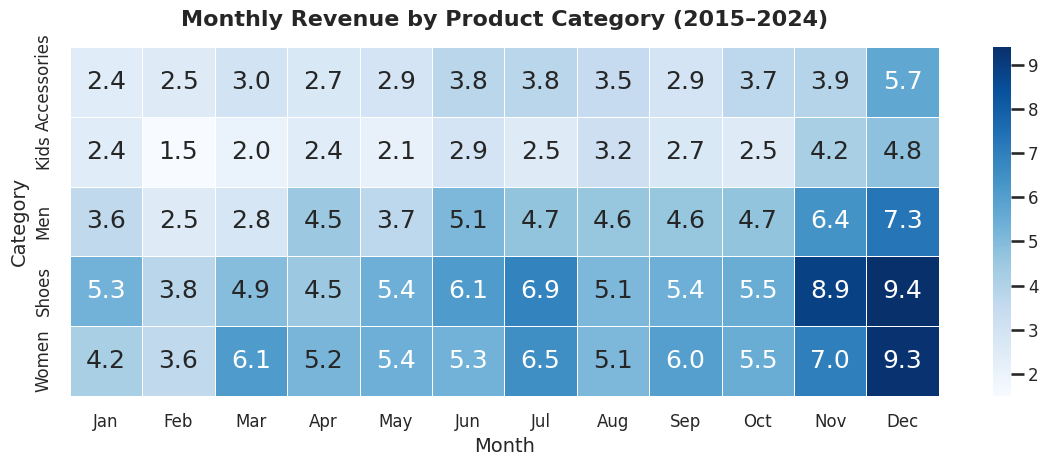

In [201]:
# Calculate monthly revenue by category
category_month = (
    sales_orders_clean
    .merge(
        products[["product_id", "category"]],
        on="product_id",
        how="left"
    )
    .groupby(
        ["month", "category"],
        as_index=False
    )
    .agg(
        revenue=("revenue", "sum")
    )
)

category_month["Revenue (M)"] = (
    category_month["revenue"] / 1_000_000
)

# Prepare heatmap matrix
category_month_pivot = (
    category_month
    .pivot(
        index="category",
        columns="month",
        values="Revenue (M)"
    )
    .round(1)
)

category_month_pivot.columns = [
    calendar.month_abbr[m]
    for m in category_month_pivot.columns
]

# Heatmap
plt.figure(figsize=(12, 5))

sns.heatmap(
    category_month_pivot,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5
)

plt.title(
    "Monthly Revenue by Product Category (2015–2024)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

Every product category followed a similar seasonal cycle, with revenue strengthening towards the end of the year, although the scale of seasonality differed considerably. Women generated the highest monthly revenue throughout most of the year, increasing from 4.2M in January to 9.3M in December. Shoes followed a similar trajectory, rising from 5.3M to 9.4M, while Accessories recorded the largest relative increase, more than doubling revenue from 2.4M to 5.7M over the same period.
The common timing of seasonal peaks indicates that year-end demand influences the entire portfolio, while differences in growth intensity suggest that categories should not be managed identically. Categories with stable year-round revenue support more predictable inventory planning, whereas categories experiencing sharper seasonal acceleration require more precise stock allocation and promotional planning ahead of peak demand. Adjusting operational decisions to category-level seasonality may improve both product availability and inventory efficiency.


##Best and Worst Performing Subcategories

In [202]:
# Calculate annual revenue by subcategory
sub_category_summary = (
    sales_orders_clean
    .merge(
        products[
            ["product_id", "category", "sub_category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby(
        ["year", "category", "sub_category"],
        as_index=False
    )
    .agg(
        revenue=("revenue", "sum")
    )
)

# Create year comparison matrix
sub_category_summary = (
    sub_category_summary
    .pivot(
        index=["category", "sub_category"],
        columns="year",
        values="revenue"
    )
)

# Reporting metrics
sub_category_summary["Total Revenue (M)"] = (
    sub_category_summary[
        list(range(2015, 2025))
    ].sum(axis=1)
    / 1_000_000
)

sub_category_summary["Growth (%)"] = (
    (
        sub_category_summary[2024]
        - sub_category_summary[2015]
    )
    / sub_category_summary[2015]
    * 100
)

# Final reporting table
sub_category_summary = (
    sub_category_summary[
        [
            "Total Revenue (M)",
            "Growth (%)"
        ]
    ]
    .sort_values(
        "Total Revenue (M)",
        ascending=False
    )
    .reset_index()
)

In [203]:
sub_category_sorted = (
    sub_category_summary
    .sort_values("Growth (%)")
)

bottom_sub_categories = (
    sub_category_sorted
    .head(3)
    .assign(
        Performance="Bottom 3"
    )
)

top_sub_categories = (
    sub_category_sorted
    .tail(3)
    .iloc[::-1]
    .assign(
        Performance="Top 3"
    )
)

In [204]:
# Sort subcategories by growth
sub_category_sorted = (
    sub_category_summary
    .sort_values("Growth (%)")
)

# Select Bottom 3 subcategories
bottom_sub_categories = (
    sub_category_sorted
    .head(3)
    .assign(
        Performance="Bottom 3"
    )
)

# Select Top 3 growing subcategories
top_sub_categories = (
    sub_category_sorted
    .tail(3)
    .iloc[::-1]
    .assign(
        Performance="Top 3"
    )
)

# Combine results
sub_category_highlights = (
    pd.concat(
        [
            top_sub_categories,
            bottom_sub_categories
        ],
        ignore_index=True
    )
    .rename(columns={
        "category": "Category",
        "sub_category": "Subcategory"
    })
)

# Display table
display(
    sub_category_highlights[
        [
            "Performance",
            "Category",
            "Subcategory",
            "Total Revenue (M)",
            "Growth (%)"
        ]
    ]
    .style
    .format({
        "Total Revenue (M)": "{:.1f}",
        "Growth (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Growth (%)"],
        cmap="Greens"
    )
    .hide(axis="index")
)

Performance,Category,Subcategory,Total Revenue (M),Growth (%)
Top 3,Women,Outerwear,10.7,254.5%
Top 3,Accessories,Belts,7.7,142.5%
Top 3,Women,Lingerie,10.7,114.0%
Bottom 3,Men,Activewear,8.0,-46.0%
Bottom 3,Men,Outerwear,9.8,-27.4%
Bottom 3,Men,Suits,7.5,-15.4%


Performance varied substantially at the subcategory level, even within categories that achieved strong overall results. Women's Outerwear recorded the highest revenue growth (+254.5%), followed by Belts (+142.5%) and Women's Lingerie (+114.0%), demonstrating that exceptional growth was concentrated in specific product lines rather than evenly distributed across categories. At the opposite end of the portfolio, all three weakest-performing subcategories belonged to the Men category, with Activewear (-46.0%), Outerwear (-27.4%) and Suits (-15.4%) experiencing sustained revenue declines.
These differences highlight the importance of analysing performance below category level. Strong category results may be driven by only a handful of successful subcategories, while weaker segments can reduce the overall effectiveness of the product portfolio. This level of analysis provides a stronger basis for assortment optimisation, inventory allocation and investment decisions than category-level performance alone.


#Customer Insights

**Objective**

This section focuses on customer behaviour and revenue concentration. It examines customer growth, purchasing patterns and revenue distribution to determine how customer retention and high-value customers contributed to long-term business performance.

##Customer Base Overview

In [205]:
# Customer purchase summary
customer_orders = (
    sales_orders_clean
    .groupby("customer_id")
    .agg(
        orders=("order_id", "nunique")
    )
)

# Key customer metrics
customer_summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Repeat Customer Share (%)",
        "Average Orders per Customer"
    ],
    "Value": [
        customer_orders.shape[0],
        (
            (customer_orders["orders"] > 1)
            .mean()
            * 100
        ),
        customer_orders["orders"].mean()
    ]
})

display(
    customer_summary.style
    .format({
        "Value": lambda x:
            f"{x:,.0f}".replace(",", " ")
            if x >= 100
            else f"{x:.1f}"
    })
    .hide(axis="index")
)

Metric,Value
Total Customers,58 900
Repeat Customer Share (%),92.6
Average Orders per Customer,4.1


The business served a total of 58,900 customers during the analysed period, with 92.6% returning to make at least one additional purchase. On average, each customer placed 4.1 orders, indicating that revenue was generated through repeated purchasing rather than predominantly one-time transactions.
These metrics suggest that customer retention played an important role in the commercial model. A customer base characterised by frequent repeat purchases is generally associated with more predictable revenue and lower acquisition costs than one relying primarily on new customers. While this summary does not measure customer lifetime value directly, it establishes a useful context for the following analyses examining how the customer base evolved over time and how revenue was distributed across different customer groups.


##Customer Base Evolution

In [206]:
# First purchase year for each customer
customer_first_year = (
    sales_orders_clean
    .groupby("customer_id")["year"]
    .min()
)

# Customers making their first purchase each year
new_customers = (
    customer_first_year
    .value_counts()
    .sort_index()
    .rename("new_customers")
)

# Active customers each year
active_customers = (
    sales_orders_clean
    .groupby("year")["customer_id"]
    .nunique()
    .rename("active_customers")
)

# Combine yearly customer metrics
customer_summary = (
    pd.concat(
        [
            active_customers,
            new_customers
        ],
        axis=1
    )
    .fillna(0)
)

customer_summary["new_customers"] = (
    customer_summary["new_customers"]
    .astype(int)
)

# Returning customers
customer_summary["returning_customers"] = (
    customer_summary["active_customers"]
    - customer_summary["new_customers"]
)

# Returning customer share
customer_summary["returning_share_pct"] = (
    customer_summary["returning_customers"]
    / customer_summary["active_customers"]
    * 100
)

customer_summary = (
    customer_summary
    .reset_index()
)

In [207]:
customer_growth = customer_summary.copy()

# Calculate cumulative customer base
customer_growth["total_customer_base"] = (
    customer_growth["new_customers"]
    .cumsum()
)

# Customer base available at the beginning of each year
customer_growth["starting_customer_base"] = (
    customer_growth["total_customer_base"]
    - customer_growth["new_customers"]
)

# Prepare reporting table
customer_growth = (
    customer_growth
    .rename(columns={
        "year": "Year",
        "starting_customer_base": "Starting Customer Base",
        "new_customers": "New Customers",
        "total_customer_base": "Total Customer Base",
        "active_customers": "Active Customers"
    })
    [
        [
            "Year",
            "Starting Customer Base",
            "New Customers",
            "Total Customer Base",
            "Active Customers"
        ]
    ]
)

display(
    customer_growth.style
    .format({
        "Starting Customer Base": lambda x: f"{x:,.0f}".replace(",", " "),
        "New Customers": lambda x: f"{x:,.0f}".replace(",", " "),
        "Total Customer Base": lambda x: f"{x:,.0f}".replace(",", " "),
        "Active Customers": lambda x: f"{x:,.0f}".replace(",", " ")
    })
    .background_gradient(
        subset=["New Customers"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Total Customer Base"],
        cmap="Greens"
    )
    .background_gradient(
        subset=["Active Customers"],
        cmap="Greys"
    )
    .hide(axis="index")
)

Year,Starting Customer Base,New Customers,Total Customer Base,Active Customers
2015,0,19 784,19 784,19 784
2016,19 784,13 294,33 078,19 908
2017,33 078,8 947,42 025,19 855
2018,42 025,5 809,47 834,19 691
2019,47 834,4 023,51 857,19 924
2020,51 857,2 707,54 564,19 814
2021,54 564,1 792,56 356,19 838
2022,56 356,1 189,57 545,19 952
2023,57 545,812,58 357,19 733
2024,58 357,543,58 900,20 080


The total customer base expanded steadily from 19,784 customers in 2015 to 58,900 in 2024, while annual new customer acquisition gradually declined from 19,784 to just 543 customers. Despite this slowdown, the number of active customers remained remarkably stable at around 19.7–20.1 thousand each year, reaching 20,080 in 2024.
This relationship indicates that business activity became increasingly dependent on existing customers rather than continuous acquisition of new ones. As the customer base matured, repeat purchasing appears to have offset the declining inflow of new customers, helping maintain a stable level of active demand. Although the underlying reasons cannot be confirmed from this analysis alone, the results suggest that customer retention became an increasingly important contributor to long-term business performance.


##Revenue Distribution Across Customer Segments

In [208]:
# Revenue generated by each customer
customer_revenue = (
    sales_orders_clean
    .groupby("customer_id", as_index=False)
    .agg(
        revenue=("revenue", "sum")
    )
    .sort_values(
        "revenue",
        ascending=False
    )
    .reset_index(drop=True)
)

# Cumulative revenue share
customer_revenue["cum_revenue_pct"] = (
    customer_revenue["revenue"]
    .cumsum()
    / customer_revenue["revenue"].sum()
    * 100
)

# Customer percentile
customer_revenue["customer_pct"] = (
    (customer_revenue.index + 1)
    / len(customer_revenue)
    * 100
)

# Revenue generated by customer groups
customer_segments = pd.DataFrame({
    "Customer Segment": [
        "Top 10%",
        "Top 25%",
        "Top 50%",
        "Bottom 50%"
    ],
    "Revenue Share (%)": [
        customer_revenue.loc[
            customer_revenue["customer_pct"] <= 10,
            "revenue"
        ].sum(),

        customer_revenue.loc[
            customer_revenue["customer_pct"] <= 25,
            "revenue"
        ].sum(),

        customer_revenue.loc[
            customer_revenue["customer_pct"] <= 50,
            "revenue"
        ].sum(),

        customer_revenue.loc[
            customer_revenue["customer_pct"] > 50,
            "revenue"
        ].sum()
    ]
})

customer_segments["Revenue Share (%)"] = (
    customer_segments["Revenue Share (%)"]
    / customer_revenue["revenue"].sum()
    * 100
)

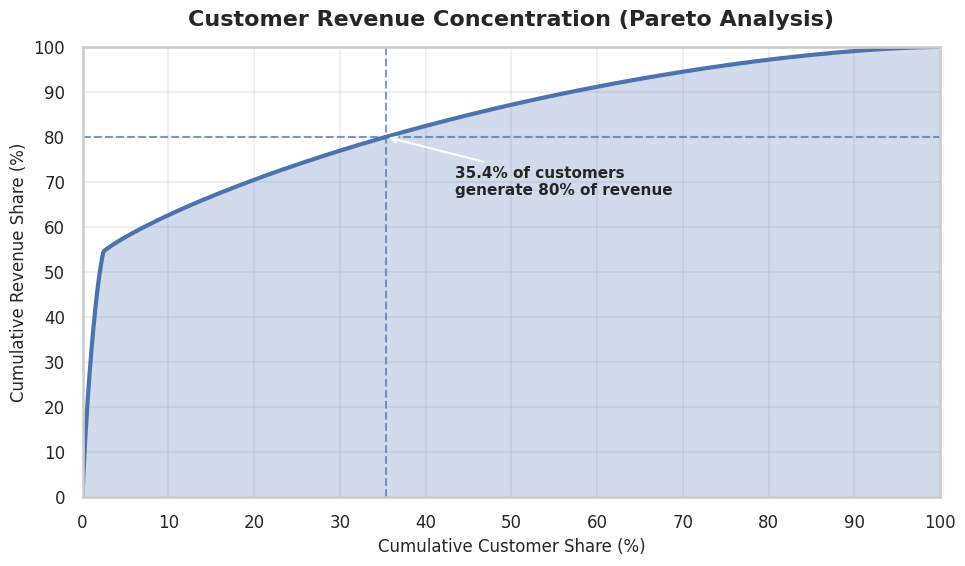

In [209]:
# Customer share responsible for 80% of revenue
pareto_80 = (
    customer_revenue.loc[
        customer_revenue["cum_revenue_pct"] >= 80,
        "customer_pct"
    ]
    .iloc[0]
)

plt.figure(figsize=(10, 6))

# Area under Pareto curve
plt.fill_between(
    customer_revenue["customer_pct"],
    customer_revenue["cum_revenue_pct"],
    alpha=0.25
)

# Pareto curve
plt.plot(
    customer_revenue["customer_pct"],
    customer_revenue["cum_revenue_pct"],
    linewidth=3
)

# Reference lines
plt.axhline(
    y=80,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

plt.axvline(
    x=pareto_80,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7
)

# Annotation
plt.annotate(
    f"{pareto_80:.1f}% of customers\ngenerate 80% of revenue",
    xy=(pareto_80, 80),
    xytext=(pareto_80 + 8, 67),
    fontsize=11,
    fontweight="bold",
    arrowprops=dict(
        arrowstyle="->",
        lw=1.5
    )
)

# Axes
plt.xlim(0, 100)
plt.ylim(0, 100)

plt.xticks(range(0, 101, 10))
plt.yticks(range(0, 101, 10))

plt.xlabel(
    "Cumulative Customer Share (%)",
    fontsize=12
)

plt.ylabel(
    "Cumulative Revenue Share (%)",
    fontsize=12
)

plt.title(
    "Customer Revenue Concentration (Pareto Analysis)",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Customer spending was highly concentrated within a relatively small proportion of the customer base. Approximately 36% of customers generated 80% of total revenue, illustrating a clear Pareto effect. Revenue concentration became even more apparent when customers were grouped into segments: the top 10% of customers contributed 62.6% of revenue, while the top 25% generated 73.8%. In contrast, the bottom 50% of customers accounted for only 12.9% of total revenue.
This distribution indicates that business performance depended disproportionately on a relatively small group of high-value customers. From a commercial perspective, retaining these customers is likely to have a greater impact on future revenue than broad acquisition strategies targeting low-value segments. At the same time, understanding the characteristics of lower-spending customers may reveal opportunities to increase their long-term value through targeted retention or cross-selling initiatives.


#Inventory Optimization

**Objective**

This section evaluates whether inventory allocation supports business performance. By comparing stock levels with revenue and sales volume, it identifies opportunities to improve inventory efficiency and better align operational decisions with commercial outcomes.

##Inventory Overview

In [210]:
# Aggregate inventory metrics by warehouse country
inventory_country = (
    inventory
    .groupby("warehouse_country")
    .agg(
        inventory_units=("stock_quantity", "sum"),
        number_of_products=("product_id", "nunique")
    )
)

# Calculate inventory share
inventory_country["Inventory Share (%)"] = (
    inventory_country["inventory_units"]
    / inventory_country["inventory_units"].sum()
    * 100
)

# Convert inventory volume to thousands of units
inventory_country["Inventory Units (K)"] = (
    inventory_country["inventory_units"]
    / 1_000
)

# Prepare reporting table
inventory_country = (
    inventory_country
    .rename(columns={
        "number_of_products": "Number of Products"
    })
    .drop(columns="inventory_units")
    .sort_values(
        "Inventory Units (K)",
        ascending=False
    )
)

inventory_country.index.name = "Warehouse Country"

# Display formatted table
display(
    inventory_country.style
    .format({
        "Inventory Units (K)": "{:.1f}",
        "Number of Products": lambda x: f"{x:,.0f}".replace(",", " "),
        "Inventory Share (%)": "{:.1f}%"
    })
    .background_gradient(
        subset=["Inventory Units (K)"],
        cmap="Blues"
    )
    .background_gradient(
        subset=["Inventory Share (%)"],
        cmap="Greens"
    )
)

,Number of Products,Inventory Share (%),Inventory Units (K)
Warehouse Country,,,
Czech Republic,1 271,33.9%,230.5
Poland,1 270,33.2%,225.6
Germany,1 200,33.0%,224.3


The inventory was distributed almost evenly across the three analysed stock groups, each representing approximately one-third of the total portfolio. The groups contained 1,271, 1,270 and 1,200 products, accounting for 33.9%, 33.2% and 33.0% of total inventory, respectively. Inventory units followed a similarly balanced distribution, ranging from 224.3K to 230.5K units.
This balanced structure indicates that inventory was not disproportionately concentrated within a single stock group, reducing operational risk associated with excessive dependence on a limited part of the assortment. While the distribution itself appears well controlled, inventory efficiency ultimately depends on whether stock allocation reflects actual customer demand, making a comparison with sales performance the next logical step.


##Inventory vs Revenue Alignment

In [211]:
# Calculate inventory volume by category
inventory_by_category = (
    inventory
    .merge(
        products[
            ["product_id", "category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        inventory_units=("stock_quantity", "sum")
    )
)

# Calculate revenue by category
revenue_by_category = (
    sales_orders_clean
    .merge(
        products[
            ["product_id", "category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        revenue=("revenue", "sum")
    )
)

# Combine inventory and revenue metrics
inventory_vs_sales = (
    inventory_by_category
    .merge(
        revenue_by_category,
        left_index=True,
        right_index=True
    )
)

# Calculate business metrics
inventory_vs_sales["Inventory Share (%)"] = (
    inventory_vs_sales["inventory_units"]
    / inventory_vs_sales["inventory_units"].sum()
    * 100
)

inventory_vs_sales["Revenue Share (%)"] = (
    inventory_vs_sales["revenue"]
    / inventory_vs_sales["revenue"].sum()
    * 100
)

inventory_vs_sales["Difference (p.p.)"] = (
    inventory_vs_sales["Inventory Share (%)"]
    - inventory_vs_sales["Revenue Share (%)"]
)

# Prepare reporting table
inventory_vs_sales = (
    inventory_vs_sales[
        [
            "Inventory Share (%)",
            "Revenue Share (%)",
            "Difference (p.p.)"
        ]
    ]
    .sort_values(
        "Difference (p.p.)",
        ascending=False
    )
)

inventory_vs_sales.index.name = "Category"

# Display results
display(
    inventory_vs_sales.style
    .format({
        "Inventory Share (%)": "{:.1f}%",
        "Revenue Share (%)": "{:.1f}%",
        "Difference (p.p.)": "{:+.1f}"
    })
    .background_gradient(
        subset=["Difference (p.p.)"],
        cmap="PuBu"
    )
)

,Inventory Share (%),Revenue Share (%),Difference (p.p.)
Category,,,
Kids,20.8%,12.3%,+8.4
Accessories,18.9%,15.2%,+3.7
Men,18.3%,20.3%,-2.0
Women,21.7%,25.8%,-4.1
Shoes,20.4%,26.4%,-6.0


Inventory allocation was not fully aligned with the revenue generated by individual product categories. Kids accounted for 20.8% of inventory while contributing only 12.3% of revenue, resulting in an 8.4 percentage point surplus. Accessories also appeared slightly overrepresented, with a 3.7 percentage point difference. In contrast, Shoes generated 26.4% of revenue despite representing only 20.4% of inventory, creating the largest inventory deficit (−6.0 percentage points). Women showed a similar pattern with a −4.1 percentage point gap.
These differences suggest that inventory allocation did not always reflect commercial performance. Categories generating a disproportionately large share of revenue may benefit from increased stock availability, while categories with excess inventory should be reviewed to determine whether demand forecasts or assortment planning require adjustment.


##Inventory vs Sales Alignment

In [212]:
# Calculate inventory volume by category
inventory_by_category = (
    inventory
    .merge(
        products[
            ["product_id", "category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        inventory_units=("stock_quantity", "sum")
    )
)

# Calculate units sold by category
units_sold_by_category = (
    sales_orders_clean
    .merge(
        products[
            ["product_id", "category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby("category")
    .agg(
        units_sold=("quantity", "sum")
    )
)

# Combine inventory and sales volume metrics
inventory_vs_units = (
    inventory_by_category
    .merge(
        units_sold_by_category,
        left_index=True,
        right_index=True
    )
)

# Calculate business metrics
inventory_vs_units["Inventory Share (%)"] = (
    inventory_vs_units["inventory_units"]
    / inventory_vs_units["inventory_units"].sum()
    * 100
)

inventory_vs_units["Units Sold Share (%)"] = (
    inventory_vs_units["units_sold"]
    / inventory_vs_units["units_sold"].sum()
    * 100
)

inventory_vs_units["Difference (p.p.)"] = (
    inventory_vs_units["Inventory Share (%)"]
    - inventory_vs_units["Units Sold Share (%)"]
)

# Prepare reporting table
inventory_vs_units = (
    inventory_vs_units[
        [
            "Inventory Share (%)",
            "Units Sold Share (%)",
            "Difference (p.p.)"
        ]
    ]
    .sort_values(
        "Difference (p.p.)",
        ascending=False
    )
)

inventory_vs_units.index.name = "Category"

# Display results
display(
    inventory_vs_units.style
    .format({
        "Inventory Share (%)": "{:.1f}%",
        "Units Sold Share (%)": "{:.1f}%",
        "Difference (p.p.)": "{:+.1f}"
    })
    .background_gradient(
        subset=["Difference (p.p.)"],
        cmap="PuBu"
    )
)

,Inventory Share (%),Units Sold Share (%),Difference (p.p.)
Category,,,
Shoes,20.4%,18.3%,+2.2
Women,21.7%,21.6%,+0.1
Kids,20.8%,21.2%,-0.4
Accessories,18.9%,19.5%,-0.6
Men,18.3%,19.5%,-1.2


Comparing inventory allocation with units sold reveals a considerably more balanced relationship than the revenue analysis alone. Differences between inventory share and unit sales remained relatively small, ranging from +2.2 percentage points for Shoes to −1.2 percentage points for Men. Women showed an almost perfect alignment, with inventory representing 21.7% of stock compared with 21.6% of units sold.
The contrast between this analysis and the previous revenue comparison indicates that inventory levels broadly reflected sales volume, but not necessarily the economic value generated by each category. Categories such as Shoes generated proportionally more revenue than their inventory share would suggest, implying stronger revenue productivity per unit stocked. Evaluating inventory against both units sold and revenue therefore provides a more complete picture of inventory efficiency than relying on volume metrics alone.


##Inventory Optimization Opportunities

In [213]:
# Calculate revenue by subcategory
subcategory_sales = (
    sales_orders_clean
    .merge(
        products[
            ["product_id", "category", "sub_category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby(
        ["category", "sub_category"],
        as_index=False
    )
    .agg(
        revenue=("revenue", "sum")
    )
)

subcategory_sales["Revenue Share (%)"] = (
    subcategory_sales["revenue"]
    / subcategory_sales["revenue"].sum()
    * 100
)

# Calculate inventory volume by subcategory
subcategory_inventory = (
    inventory
    .merge(
        products[
            ["product_id", "category", "sub_category"]
        ],
        on="product_id",
        how="left"
    )
    .groupby(
        ["category", "sub_category"],
        as_index=False
    )
    .agg(
        inventory_units=("stock_quantity", "sum")
    )
)

subcategory_inventory["Inventory Share (%)"] = (
    subcategory_inventory["inventory_units"]
    / subcategory_inventory["inventory_units"].sum()
    * 100
)

# Combine inventory and revenue metrics
subcategory_inventory_vs_sales = (
    subcategory_inventory
    .merge(
        subcategory_sales[
            [
                "category",
                "sub_category",
                "Revenue Share (%)"
            ]
        ],
        on=[
            "category",
            "sub_category"
        ],
        how="left"
    )
)

# Calculate inventory imbalance
subcategory_inventory_vs_sales["Difference (p.p.)"] = (
    subcategory_inventory_vs_sales["Inventory Share (%)"]
    - subcategory_inventory_vs_sales["Revenue Share (%)"]
)

# Prepare reporting table
subcategory_inventory_vs_sales = (
    subcategory_inventory_vs_sales
    .sort_values(
        "Difference (p.p.)",
        ascending=False
    )
)

In [214]:
# Sort subcategories by inventory imbalance
subcategory_inventory_sorted = (
    subcategory_inventory_vs_sales
    .sort_values("Difference (p.p.)")
)

# Select the most understocked subcategories
top_understocked = (
    subcategory_inventory_sorted
    .head(3)
    .assign(
        Performance="Understocked"
    )
)

# Select the most overstocked subcategories
top_overstocked = (
    subcategory_inventory_sorted
    .tail(3)
    .iloc[::-1]
    .assign(
        Performance="Overstocked"
    )
)

# Combine results
inventory_imbalance_summary = (
    pd.concat(
        [
            top_overstocked,
            top_understocked
        ],
        ignore_index=True
    )
    .rename(columns={
        "category": "Category",
        "sub_category": "Subcategory"
    })
)

# Display business summary
display(
    inventory_imbalance_summary[
        [
            "Performance",
            "Category",
            "Subcategory",
            "Inventory Share (%)",
            "Revenue Share (%)",
            "Difference (p.p.)"
        ]
    ]
    .style
    .format({
        "Inventory Share (%)": "{:.1f}%",
        "Revenue Share (%)": "{:.1f}%",
        "Difference (p.p.)": "{:+.1f}"
    })
    .background_gradient(
        subset=["Difference (p.p.)"],
        cmap="PuBu"
    )
    .hide(axis="index")
)

Performance,Category,Subcategory,Inventory Share (%),Revenue Share (%),Difference (p.p.)
Overstocked,Kids,Tops,4.5%,2.7%,+1.9
Overstocked,Kids,Bottoms,3.7%,1.9%,+1.8
Overstocked,Kids,Shoes,4.3%,2.6%,+1.7
Understocked,Shoes,Sandals,3.7%,5.5%,-1.7
Understocked,Shoes,Sneakers,4.0%,5.6%,-1.5
Understocked,Women,Jeans,3.8%,5.2%,-1.5


**Summary**

The subcategory-level analysis confirms the pattern observed at the category level. The largest inventory surpluses were concentrated within the Kids category, where all major subcategories showed a higher inventory share than revenue share. This suggests that the inventory imbalance is not driven by a single product group but is present across the broader Kids portfolio.

On the opposite side, the strongest inventory deficits were observed in Shoes and Women subcategories. Sandals, Sneakers, Loafers, Jeans, and Dresses generated a larger share of revenue than their share of inventory, indicating stronger sales performance relative to current stock allocation.

Overall, the findings suggest that inventory imbalances are systematic rather than isolated to individual products. The results reinforce the earlier conclusion that inventory appears to be concentrated in Kids products, while Shoes and Women categories generate proportionally stronger sales relative to their inventory levels.

#Executive Conclusions

The analysis demonstrates that the company's revenue growth between 2015 and 2024 was driven primarily by increasing customer spending rather than higher transaction volumes. Revenue increased by 44.2%, while annual order volume remained almost unchanged at approximately 24 thousand orders. At the same time, Average Order Value grew by 41.9%, indicating that customers consistently spent more per purchase.

Several complementary analyses explain this pattern. Average product prices increased by approximately 36.8%, the share of High-End products nearly doubled from 19.4% to 37.0%, while Premium products expanded from 1.9% to 16.1%. Newly launched products also became progressively more expensive, suggesting that portfolio evolution contributed alongside pricing to higher transaction values.

Revenue growth was not evenly distributed across the business. Categories such as Women (+78.9%) and Accessories (+77.8%) generated most of the commercial expansion, whereas the Men category declined by 5.1% despite higher average prices. Product-level analysis showed that successful categories combined price growth with sustained customer demand, while higher prices alone were insufficient to offset declining sales volumes.

Customer behaviour also played an important role in business performance. The company built a customer base of 58,900 customers, 92.6% of whom returned for additional purchases, with an average of 4.1 orders per customer. Revenue, however, remained highly concentrated: only 36% of customers generated 80% of total revenue, while the top 10% alone accounted for 62.6%. This indicates that a relatively small segment of customers created a disproportionate share of business value.

Operational analyses revealed that inventory allocation was generally balanced but not always aligned with commercial performance. Categories such as Shoes and Women generated a larger share of revenue than their inventory allocation, whereas Kids remained comparatively overstocked relative to its revenue contribution. This suggests that inventory optimisation may further improve operational efficiency without increasing overall stock levels.

Taken together, the findings indicate that the company achieved sustainable revenue growth through premiumisation, portfolio evolution and strong customer retention rather than aggressive discounting or higher sales volumes. The business appears to compete by increasing customer value instead of relying on transaction quantity.

#Business Recommendations

Based on the findings, several opportunities could further strengthen long-term business performance.

Continue developing higher-value product categories. Women and Accessories consistently outperformed the rest of the portfolio, while premium product segments expanded substantially throughout the analysed period. Maintaining investment in these categories is likely to generate stronger returns than distributing resources evenly across the entire assortment.

Review the Men's category strategy. Revenue declined despite a 36.0% increase in average prices, accompanied by lower order volume and fewer units sold. Additional product-level analysis should determine whether the decline reflects assortment decisions, changing customer preferences or pricing that exceeded market expectations.

Prioritise customer retention alongside acquisition. The high repeat customer rate and strong revenue concentration among top customers suggest that retaining existing high-value customers may produce greater commercial impact than focusing exclusively on acquiring new ones. Loyalty initiatives and personalised marketing may therefore offer attractive opportunities, although their effectiveness would require further validation.

Optimise inventory based on commercial value rather than stock balance alone. Categories generating disproportionately high revenue, particularly Shoes and Women, may justify greater inventory allocation, while categories with excess inventory relative to revenue should be reviewed to reduce capital tied up in slower-performing products.

Maintain selective promotional activity. Most revenue was generated with discounts below 20%, indicating that the business has been able to sustain demand without relying on deep price reductions. Continuing a targeted promotional strategy may help protect both pricing power and long-term profitability.

#Potential Next Steps

This analysis was based exclusively on transactional sales, product, customer and inventory data. While these datasets provided sufficient information to explain historical business performance, several important business questions could not be investigated due to data limitations.

The dataset did not include marketing campaign data, making it impossible to evaluate the effectiveness of individual campaigns or determine whether revenue growth was influenced by advertising activities. Similarly, the absence of product cost and profit margin information prevented an assessment of profitability, meaning the analysis focused on revenue rather than financial performance.

Customer-level behavioural data was also limited. Information such as customer demographics, acquisition channels, marketing touchpoints or customer lifetime value was unavailable, restricting the ability to perform more advanced customer segmentation or retention analysis. In addition, the dataset contained no information on competitor pricing, market conditions or external events, making it impossible to distinguish internal business decisions from external market influences.

Future analyses could therefore extend this project by integrating marketing, financial and customer behavioural data. Combining these sources would enable profitability analysis, campaign effectiveness measurement, customer lifetime value modelling, acquisition channel evaluation and more advanced forecasting, providing a broader foundation for strategic business decision-making.